In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did


In [2]:
with open('./data/cell_lineage.json', 'r', encoding='utf-8') as f:
    lineage_data = json.load(f)
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0 :
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(len(intermediate_nodes), len(terminal_nodes))

1091 1092


In [3]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
cell_type_dict = {}
for node in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur_cell_type_df) == 0:
        print(f"Warning: No cell type found for {node}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        # print(f"Warning: No valid cell type found for {node}")
        cell_type_dict[node] = "programmed_death"
        continue
    if len(cur_lineage_types) > 1:
        print(f"Warning: Multiple cell types found for {node}: {cur_lineage_types}")
    cur_type = cur_lineage_types[0]
    cell_type_dict[node] = cur_type

In [4]:
# one hot encoding of cell types, meaining each cell is assigned an one-hot vector corresponding to its type, this is used for the cell type prediction task
# rank the cell types by their frequency and assign an integer to each type
# programmed_death should be assigned as the last tpye since it's kind of special
cell_types = list(set(cell_type_dict.values()))
cell_types = [ct for ct in cell_types if ct != "programmed_death"]
cell_types = sorted(cell_types, key=lambda x: sum([1 for v in cell_type_dict.values() if v == x]), reverse=True)
cell_types.append("programmed_death")
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}
cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    one_hot = np.zeros(len(cell_types))
    one_hot[cell_type_to_int[ct]] = 1
    cell_type_one_hot[node] = one_hot


In [5]:
# for internal node, the cell type is calculated as the sum of all its descendant terminal nodes'
# one-hot vectors and then normalized to get a distribution over cell types, this is used for the cell type prediction task
for node in intermediate_nodes:
    descendant_types = [cell_type_one_hot[desc] for desc in descendant_list_dict[node]]
    if len(descendant_types) == 0:
        print(f"Warning: No descendant types found for {node}")
        cell_type_one_hot[node] = np.zeros(len(cell_types))
        continue
    summed_types = np.sum(descendant_types, axis=0)
    normalized_types = summed_types / np.sum(summed_types)
    cell_type_one_hot[node] = normalized_types

In [6]:
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0).T
protein_exp = protein_exp.fillna(0)

In [7]:
protein_exp.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
AHR-1_SYS571,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_RW10757,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_SYS139,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALY-1_SYS619,0.0,0.0,0.0,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.3,85.99,42.42,41.02,0.0,0.0,0.0,0.0,0.0


In [8]:
# z-score normalization for each gene across all cells
# genes are rows and cells are columns, so we need to normalize across columns for each row
# but first, get rid of the genes that all all zero across all cells, since they are not informative at all and will cause problems for z-score normalization
protein_exp = protein_exp[~(protein_exp == 0).all(axis=1)]
protein_exp_zscore = protein_exp.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
protein_exp_zscore.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,...,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020
ALR-1_RW10757,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,...,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592
ALR-1_SYS139,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,...,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730
ALY-1_SYS619,-1.574885,-1.574885,-1.574885,-0.827994,1.868800,1.721845,2.516075,0.871300,-0.218186,0.167487,...,-0.103988,-0.087385,0.354377,-0.623154,-0.654564,-1.574885,-1.574885,-1.574885,-1.574885,-1.574885
ALY-2_SYS721,-1.899774,0.540951,0.282820,-0.438411,1.413989,-0.005436,0.402139,-0.413011,0.229067,-0.008389,...,0.939666,1.108012,1.089110,0.777817,-0.046784,0.071944,0.232612,0.918992,5.526953,5.323166


In [9]:
# save protein_exp_zscore to csv for latter use in "./data/protein/aggregated_all/s3_zscore.csv"
protein_exp_zscore.to_csv("./data/protein/aggregated_all/s3_zscore.csv")

In [10]:
# set up training data
# X will be the value of protein_exp_zscore
# y will be the cell type one-hot vector
X = protein_exp_zscore.values.T
y = np.array([cell_type_one_hot[map_names(node)] for node in protein_exp_zscore.columns])
print(X.shape, y.shape)

(1204, 210) (1204, 18)


In [11]:
# for each sample, there is also consideration given to the difference between hard labels and soft mixed labels
# it should be the inverse of how many descendant terminal nodes it has, since the more descendant terminal nodes it has, the softer the label is, and the less weight it should have in the training process
sample_weights = np.array([1/len(descendant_list_dict[map_names(node)]) if len(descendant_list_dict[map_names(node)]) > 0 else 1 for node in protein_exp_zscore.columns])
print(sample_weights.shape)

(1204,)


Terminal (hard): 494  |  Intermediate (soft): 710


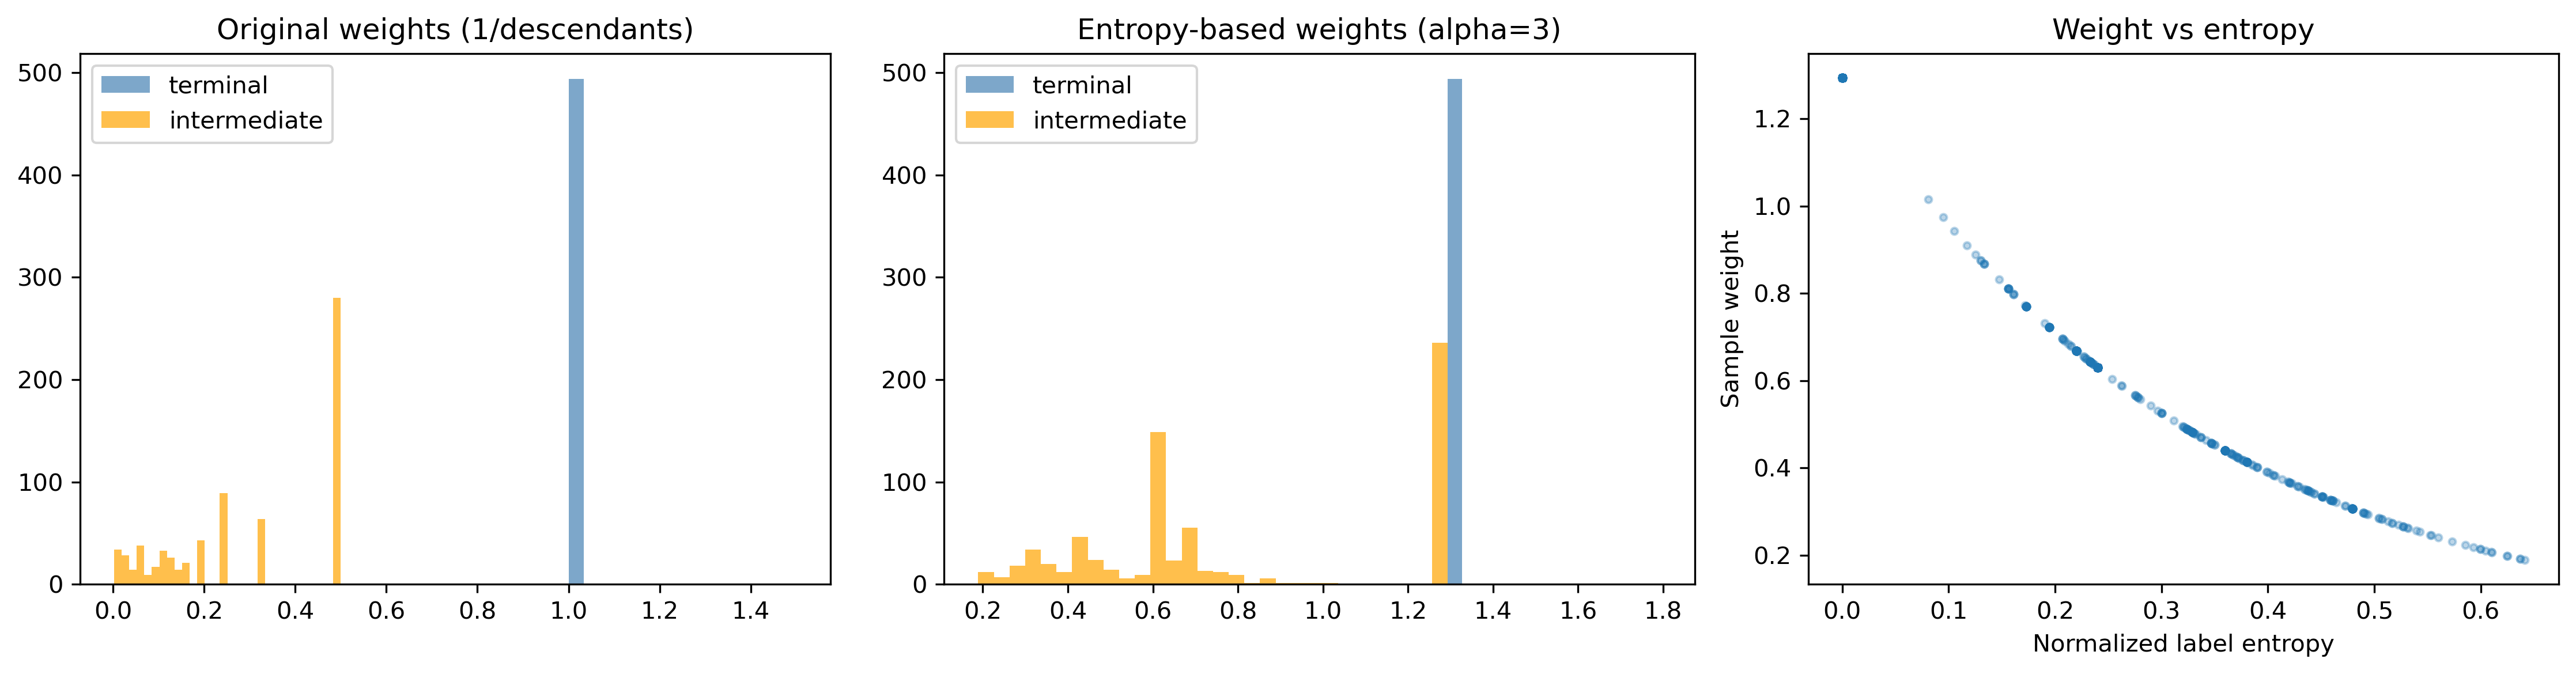

Hard nodes  – mean_w=1.294, max_w=1.294
Soft nodes  – mean_w=0.796, max_w=1.294


In [12]:

# === Improved Sample Weights: Entropy-Based ===
# 
# The original 1/num_descendants scheme is a proxy for label hardness, but
# entropy of the soft label directly measures uncertainty regardless of tree depth.
# Hard (terminal) nodes have one-hot labels → H=0 → weight≈1.
# Soft (intermediate) nodes have mixed labels → H>0 → weight<1.

def entropy_based_weights(y_soft, alpha=3.0):
    """
    alpha: sharpness. Higher alpha → harder labels get even more relative weight.
    Returns weights normalized so mean=1.
    """
    y_clipped = np.clip(y_soft, 1e-10, 1.0)
    entropies = -np.sum(y_clipped * np.log(y_clipped), axis=1)
    max_ent = np.log(y_soft.shape[1])
    norm_ent = entropies / max_ent          # 0=hard/one-hot, 1=uniform
    weights = np.exp(-alpha * norm_ent)
    return (weights / weights.mean()).astype(np.float32)

sample_weights_v2 = entropy_based_weights(y, alpha=3.0)

# Mask for terminal (hard-label) vs intermediate (soft-label) nodes
terminal_mask = np.array([
    len(descendant_list_dict[map_names(node)]) == 0
    for node in protein_exp_zscore.columns
])
print(f"Terminal (hard): {terminal_mask.sum()}  |  Intermediate (soft): {(~terminal_mask).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample_weights[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[0].hist(sample_weights[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[0].set_title('Original weights (1/descendants)')
axes[0].legend()

axes[1].hist(sample_weights_v2[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[1].hist(sample_weights_v2[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[1].set_title('Entropy-based weights (alpha=3)')
axes[1].legend()

norm_ent_all = -np.sum(np.clip(y, 1e-10,1) * np.log(np.clip(y, 1e-10,1)), axis=1) / np.log(y.shape[1])
axes[2].scatter(norm_ent_all, sample_weights_v2, alpha=0.3, s=8)
axes[2].set_xlabel('Normalized label entropy')
axes[2].set_ylabel('Sample weight')
axes[2].set_title('Weight vs entropy')

plt.tight_layout()
plt.show()

print(f"Hard nodes  – mean_w={sample_weights_v2[terminal_mask].mean():.3f}, max_w={sample_weights_v2[terminal_mask].max():.3f}")
print(f"Soft nodes  – mean_w={sample_weights_v2[~terminal_mask].mean():.3f}, max_w={sample_weights_v2[~terminal_mask].max():.3f}")


In [13]:

from feature_selection import (
    SparseGateClassifier,
    FocusedClassifier,
    soft_cross_entropy,
    train_epoch,
    eval_accuracy,
    cross_validate_features,
    train_one_pass,
    train_focused,
)

print("feature_selection module loaded.")
print("  Models   : SparseGateClassifier, FocusedClassifier")
print("  Functions: cross_validate_features, train_one_pass, train_focused")


feature_selection module loaded.
  Models   : SparseGateClassifier, FocusedClassifier
  Functions: cross_validate_features, train_one_pass, train_focused


In [14]:

# Training utilities (soft_cross_entropy, train_epoch, eval_accuracy,
# entropy_based_weights) are provided by feature_selection.py and imported
# in the cell above. Nothing to define here.


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Device: cuda


CV configs: 100%|██████████| 18/18 [08:05<00:00, 26.98s/it]


Top-5 configs by composite score  (val_acc × mean_jaccard):


,l1_lambda,hidden_dims,dropout,mean_val_acc,std_val_acc,mean_train_acc,mean_overfit_gap,mean_jaccard,std_jaccard,mean_spearman,score
0,0.008,"(128, 64, 32)",0.2,0.7312,0.0157,0.9990,0.2678,0.4707,0.1044,0.8367,0.3442
1,0.002,"(128, 64, 32)",0.2,0.7292,0.0216,0.9990,0.2698,0.4705,0.1009,0.8674,0.3430
2,0.002,"(128, 64, 32)",0.3,0.7192,0.0190,0.9955,0.2762,0.4547,0.0881,0.8739,0.3270
3,0.004,"(128, 64)",0.3,0.7310,0.0288,1.0000,0.2690,0.4440,0.1091,0.8622,0.3245
4,0.008,"(128, 64)",0.3,0.7224,0.0191,1.0000,0.2776,0.4431,0.1069,0.8346,0.3201



Best config: {'l1_lambda': 0.008, 'hidden_dims': (128, 64, 32), 'dropout': 0.2}


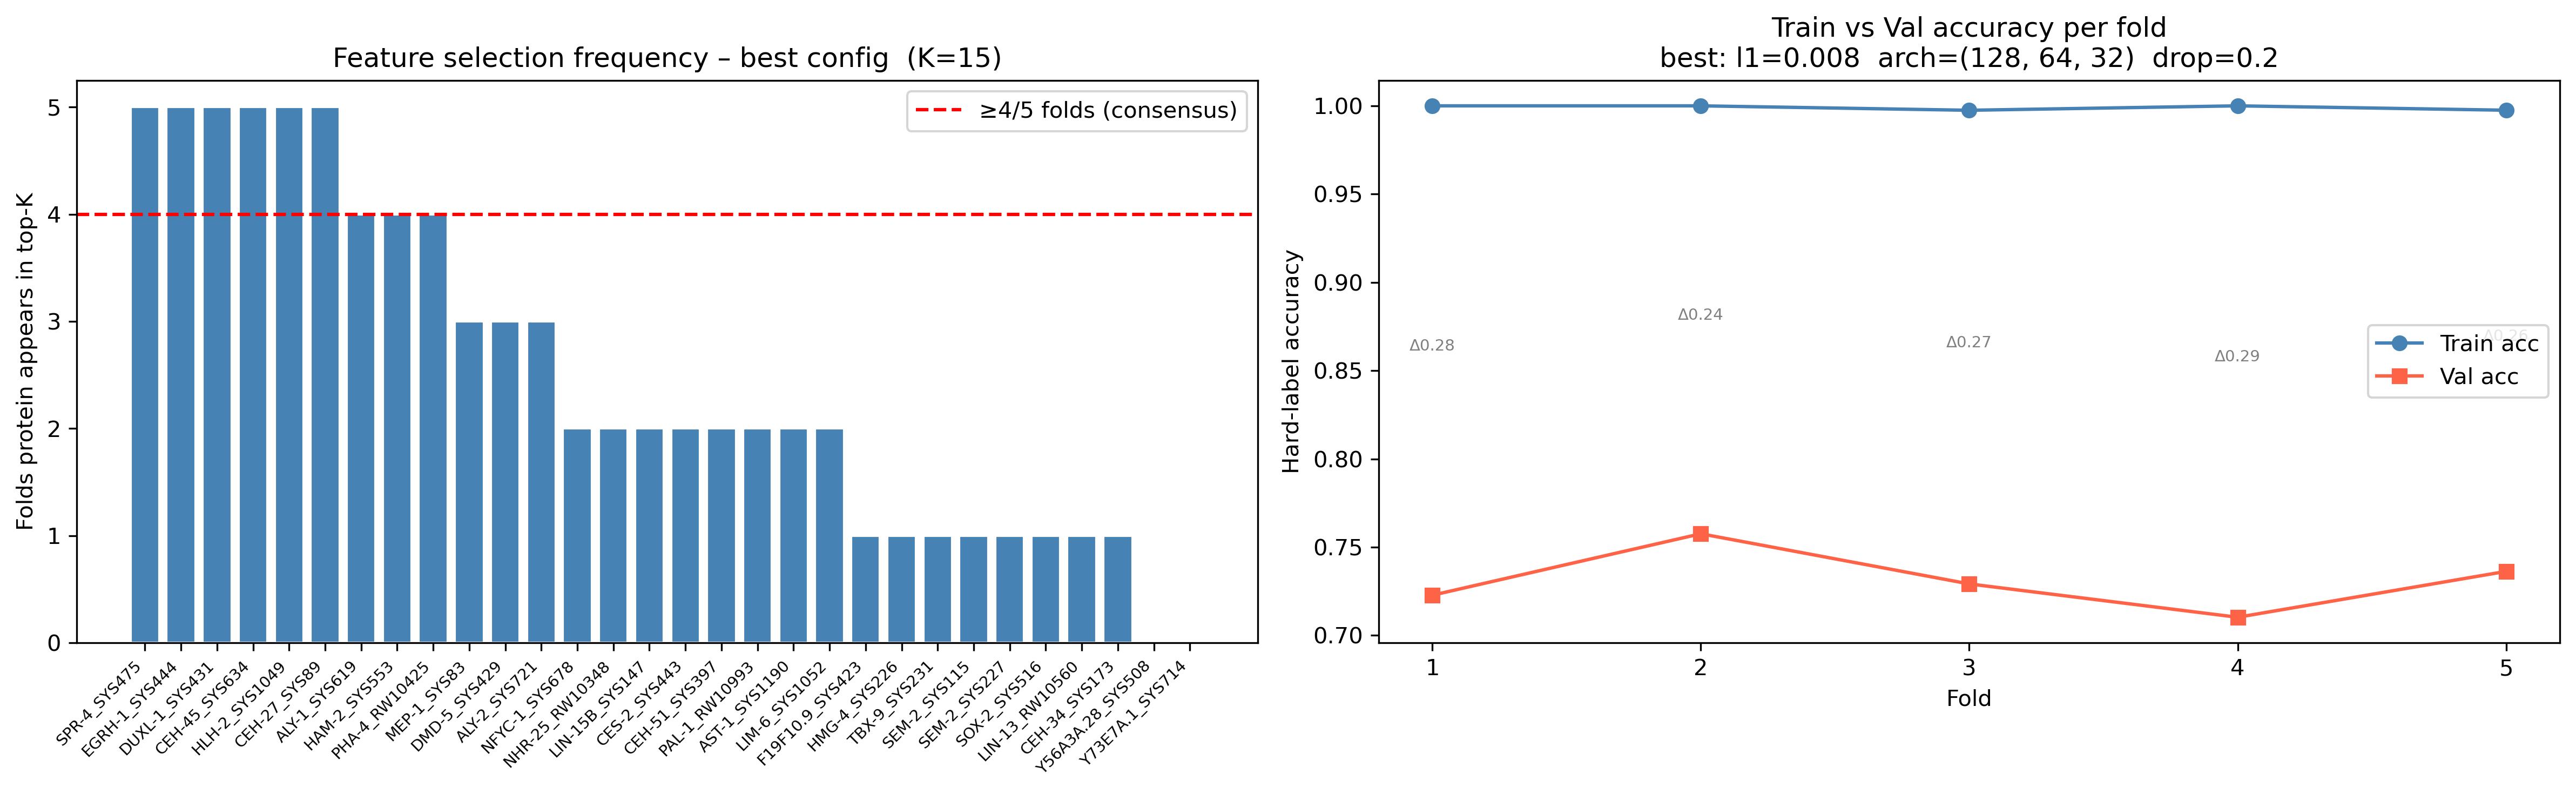


Feature stability (best config):
  Mean Jaccard  : 0.4707 ± 0.1044
  Mean Spearman : 0.8367
  Overfitting   : train=0.999  val=0.731  gap=0.268
  Consensus features (≥4/5 folds, n=9): [np.str_('ALY-1_SYS619'), np.str_('CEH-27_SYS89'), np.str_('CEH-45_SYS634'), np.str_('DUXL-1_SYS431'), np.str_('EGRH-1_SYS444'), np.str_('HAM-2_SYS553'), np.str_('HLH-2_SYS1049'), np.str_('PHA-4_RW10425'), np.str_('SPR-4_SYS475')]


In [15]:

import torch
import torch.nn.functional as F

# ─── Device & shared tensors ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

feature_names = np.array(protein_exp_zscore.index.tolist())
N_SELECT      = 15

X_t    = torch.FloatTensor(X)
y_t    = torch.FloatTensor(y)
w_t    = torch.FloatTensor(sample_weights_v2)
term_t = torch.BoolTensor(terminal_mask)

# ─── Cross-Validation: hyperparameter grid search ────────────────────────────
#
# Three axes are explored jointly:
#   l1_lambda   – controls gate sparsity (how aggressively features are pruned)
#   hidden_dims – architecture of the backbone; last dim = embedding dimension
#   dropout     – regularisation strength
#
# Configs are ranked by composite score = val_acc × mean_jaccard, which
# rewards both predictive power AND stable feature selection across folds.

param_grid = {
    'l1_lambda':   [0.002, 0.004, 0.008],
    'hidden_dims': [(128, 64), (128, 64, 32), (64, 32)],
    'dropout':     [0.2, 0.3],
}

CV_EPOCHS = 300

cv_results, best_config = cross_validate_features(
    X, y, sample_weights_v2, terminal_mask,
    param_grid = param_grid,
    n_splits   = 5,
    n_select   = N_SELECT,
    n_epochs   = CV_EPOCHS,
    device     = str(device),
)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for r in cv_results:
    row = {**r['config'], **r['summary'], 'score': round(r['score'], 5)}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('score', ascending=False)
print(f"\nTop-5 configs by composite score  (val_acc × mean_jaccard):")
display(summary_df.head().round(4))
print(f"\nBest config: {best_config}")

# ── Visualisation ─────────────────────────────────────────────────────────────
best_result  = cv_results[0]
freq         = best_result['stability']['feature_frequency']
top_freq_idx = np.argsort(freq)[::-1][:N_SELECT * 2]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature-selection frequency bar chart
ax = axes[0]
ax.bar(range(len(top_freq_idx)), freq[top_freq_idx],
       color='steelblue', edgecolor='white')
ax.set_xticks(range(len(top_freq_idx)))
ax.set_xticklabels(
    [feature_names[i] for i in top_freq_idx],
    rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Folds protein appears in top-K')
ax.set_title(f'Feature selection frequency – best config  (K={N_SELECT})')
ax.axhline(4, color='red', linestyle='--', label='≥4/5 folds (consensus)')
ax.legend()

# Per-fold train vs val accuracy with overfit-gap annotations
ax = axes[1]
fold_train = [fr['train_acc'] for fr in best_result['fold_results']]
fold_val   = [fr['val_acc']   for fr in best_result['fold_results']]
folds_x    = list(range(1, len(fold_train) + 1))
ax.plot(folds_x, fold_train, 'o-', label='Train acc', color='steelblue')
ax.plot(folds_x, fold_val,   's-', label='Val acc',   color='tomato')
for i, (tr, va) in enumerate(zip(fold_train, fold_val)):
    ax.annotate(f'Δ{tr - va:.2f}', xy=(i + 1, (tr + va) / 2),
                ha='center', fontsize=7, color='gray')
ax.set_xlabel('Fold')
ax.set_ylabel('Hard-label accuracy')
ax.set_title(
    f'Train vs Val accuracy per fold\n'
    f'best: l1={best_config.get("l1_lambda")}  '
    f'arch={best_config.get("hidden_dims")}  '
    f'drop={best_config.get("dropout")}')
ax.set_xticks(folds_x)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nFeature stability (best config):")
print(f"  Mean Jaccard  : {best_result['summary']['mean_jaccard']:.4f} ± {best_result['summary']['std_jaccard']:.4f}")
print(f"  Mean Spearman : {best_result['summary']['mean_spearman']:.4f}")
print(f"  Overfitting   : train={best_result['summary']['mean_train_acc']:.3f}  "
      f"val={best_result['summary']['mean_val_acc']:.3f}  "
      f"gap={best_result['summary']['mean_overfit_gap']:.3f}")
consensus_names = [feature_names[i] for i in best_result['stability']['consensus_features']]
print(f"  Consensus features (≥4/5 folds, n={len(consensus_names)}): {consensus_names}")


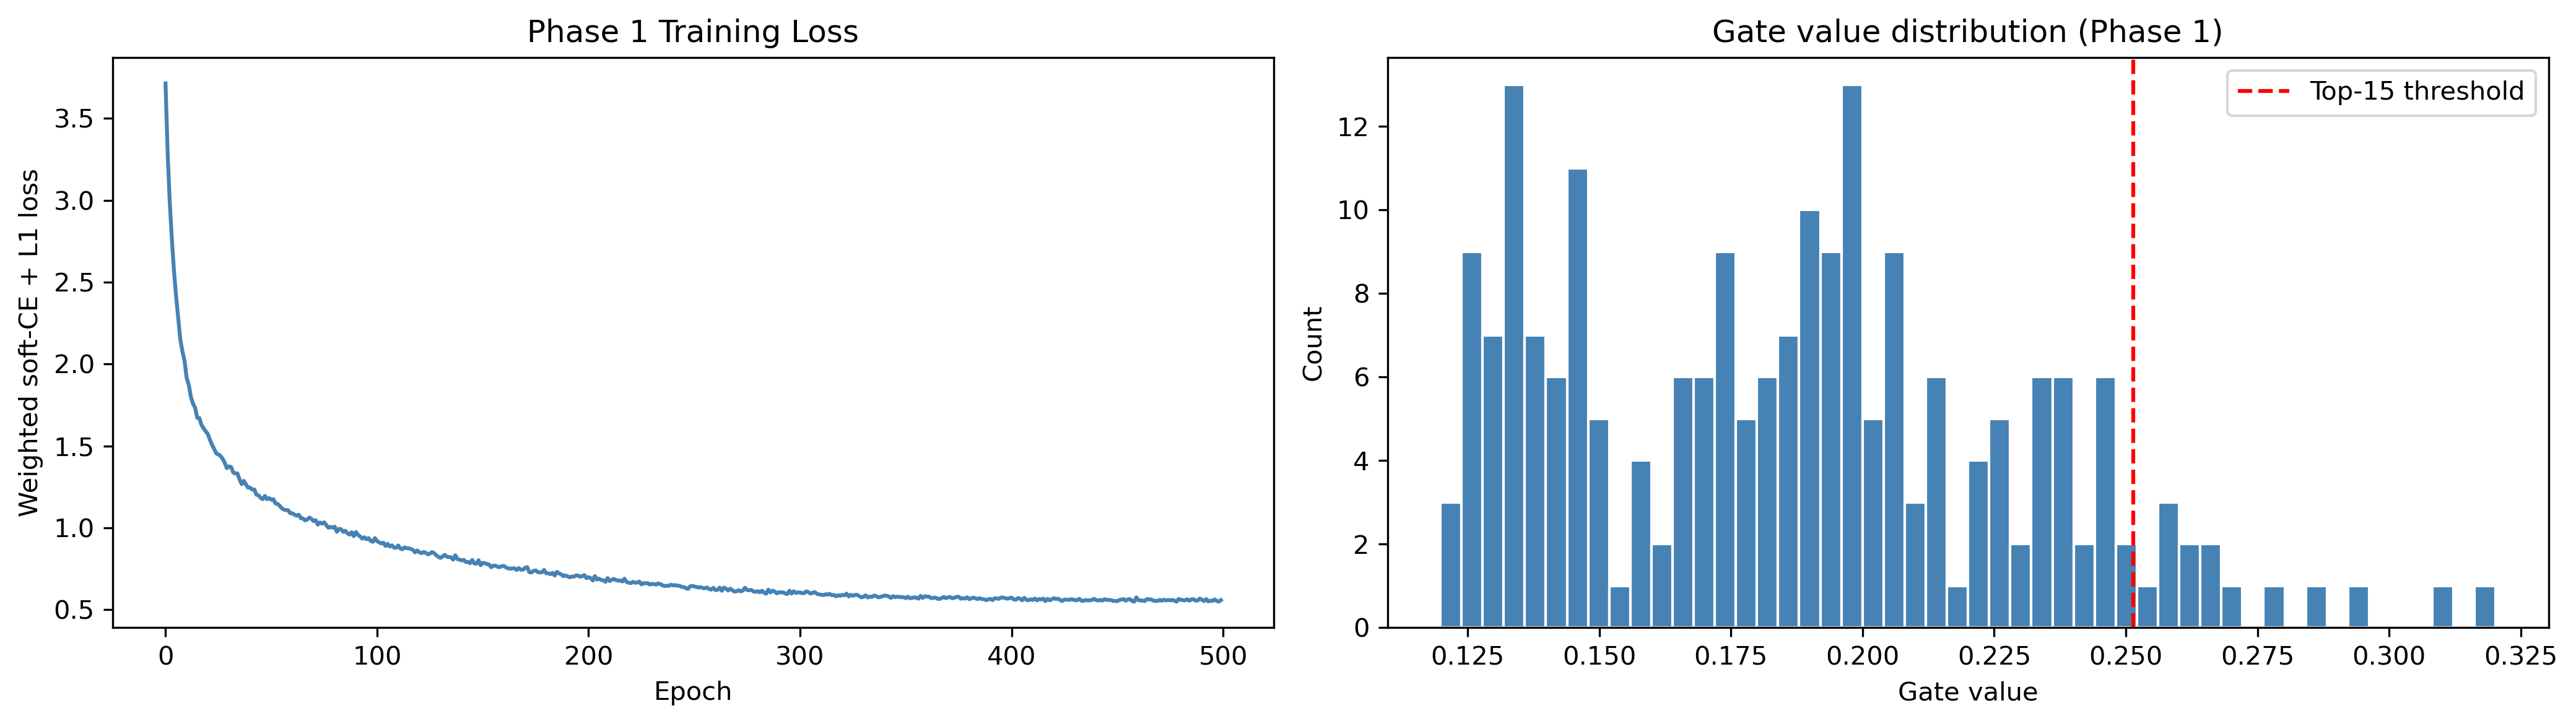

Phase 1 terminal accuracy : 1.0000
Selected 15 features: ['HLH-2_SYS1049', 'CEH-45_SYS634', 'DUXL-1_SYS431', 'PHA-4_RW10425', 'CEH-27_SYS89', 'SPR-4_SYS475', 'MEP-1_SYS83', 'CES-2_SYS443', 'HAM-2_SYS553', 'ALY-1_SYS619', 'EGRH-1_SYS444', 'ALY-2_SYS721', 'CEH-51_SYS397', 'NHR-25_RW10348', 'NFYC-1_SYS678']


In [20]:

# ─── Phase 1: Final feature-selection training (full dataset, CV-validated config) ──
#
# train_one_pass() trains SparseGateClassifier on ALL samples using the
# best hyperparameter config from cross-validation.  The resulting gate
# values determine the N_SELECT most important features.
#
# The penultimate embedding from Phase 1 (_emb_p1) is intentionally
# discarded — it is trained on the full gated input and correlates poorly
# with pairwise distances in the original expression space.
# Phase 2 (train_focused) produces the distance-consistent embedding.

model_sparse, top_idx, gate_vals, _emb_p1, losses_p1 = train_one_pass(
    X, y, sample_weights_v2,
    hidden_dims = best_config['hidden_dims'],
    l1_lambda   = best_config['l1_lambda'],
    dropout     = best_config.get('dropout', 0.3),
    n_select    = N_SELECT,
    n_epochs    = 500,
    device      = str(device),
)

X_sel   = X[:, top_idx].astype(np.float32)
X_sel_t = torch.FloatTensor(X_sel)

# ── Training diagnostics ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(losses_p1, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted soft-CE + L1 loss')
ax.set_title('Phase 1 Training Loss')

ax = axes[1]
ax.hist(gate_vals, bins=50, color='steelblue', edgecolor='white')
ax.axvline(np.sort(gate_vals)[::-1][N_SELECT - 1],
           color='red', linestyle='--', label=f'Top-{N_SELECT} threshold')
ax.set_xlabel('Gate value')
ax.set_ylabel('Count')
ax.set_title('Gate value distribution (Phase 1)')
ax.legend()

plt.tight_layout()
plt.show()

final_acc_p1 = eval_accuracy(model_sparse, torch.FloatTensor(X).to(device), y_t, term_t, device)
print(f"Phase 1 terminal accuracy : {final_acc_p1:.4f}")
print(f"Selected {N_SELECT} features: {feature_names[top_idx].tolist()}")


Rank  Feature                                Gate
--------------------------------------------------
   1   HLH-2_SYS1049                        0.3202
   2   CEH-45_SYS634                        0.3118
   3   DUXL-1_SYS431                        0.2942
   4   PHA-4_RW10425                        0.2867
   5   CEH-27_SYS89                         0.2778
   6   SPR-4_SYS475                         0.2688
   7   MEP-1_SYS83                          0.2660
   8   CES-2_SYS443                         0.2656
   9   HAM-2_SYS553                         0.2627
  10   ALY-1_SYS619                         0.2612
  11   EGRH-1_SYS444                        0.2598
  12   ALY-2_SYS721                         0.2593
  13   CEH-51_SYS397                        0.2574
  14   NHR-25_RW10348                       0.2544
  15   NFYC-1_SYS678                        0.2514


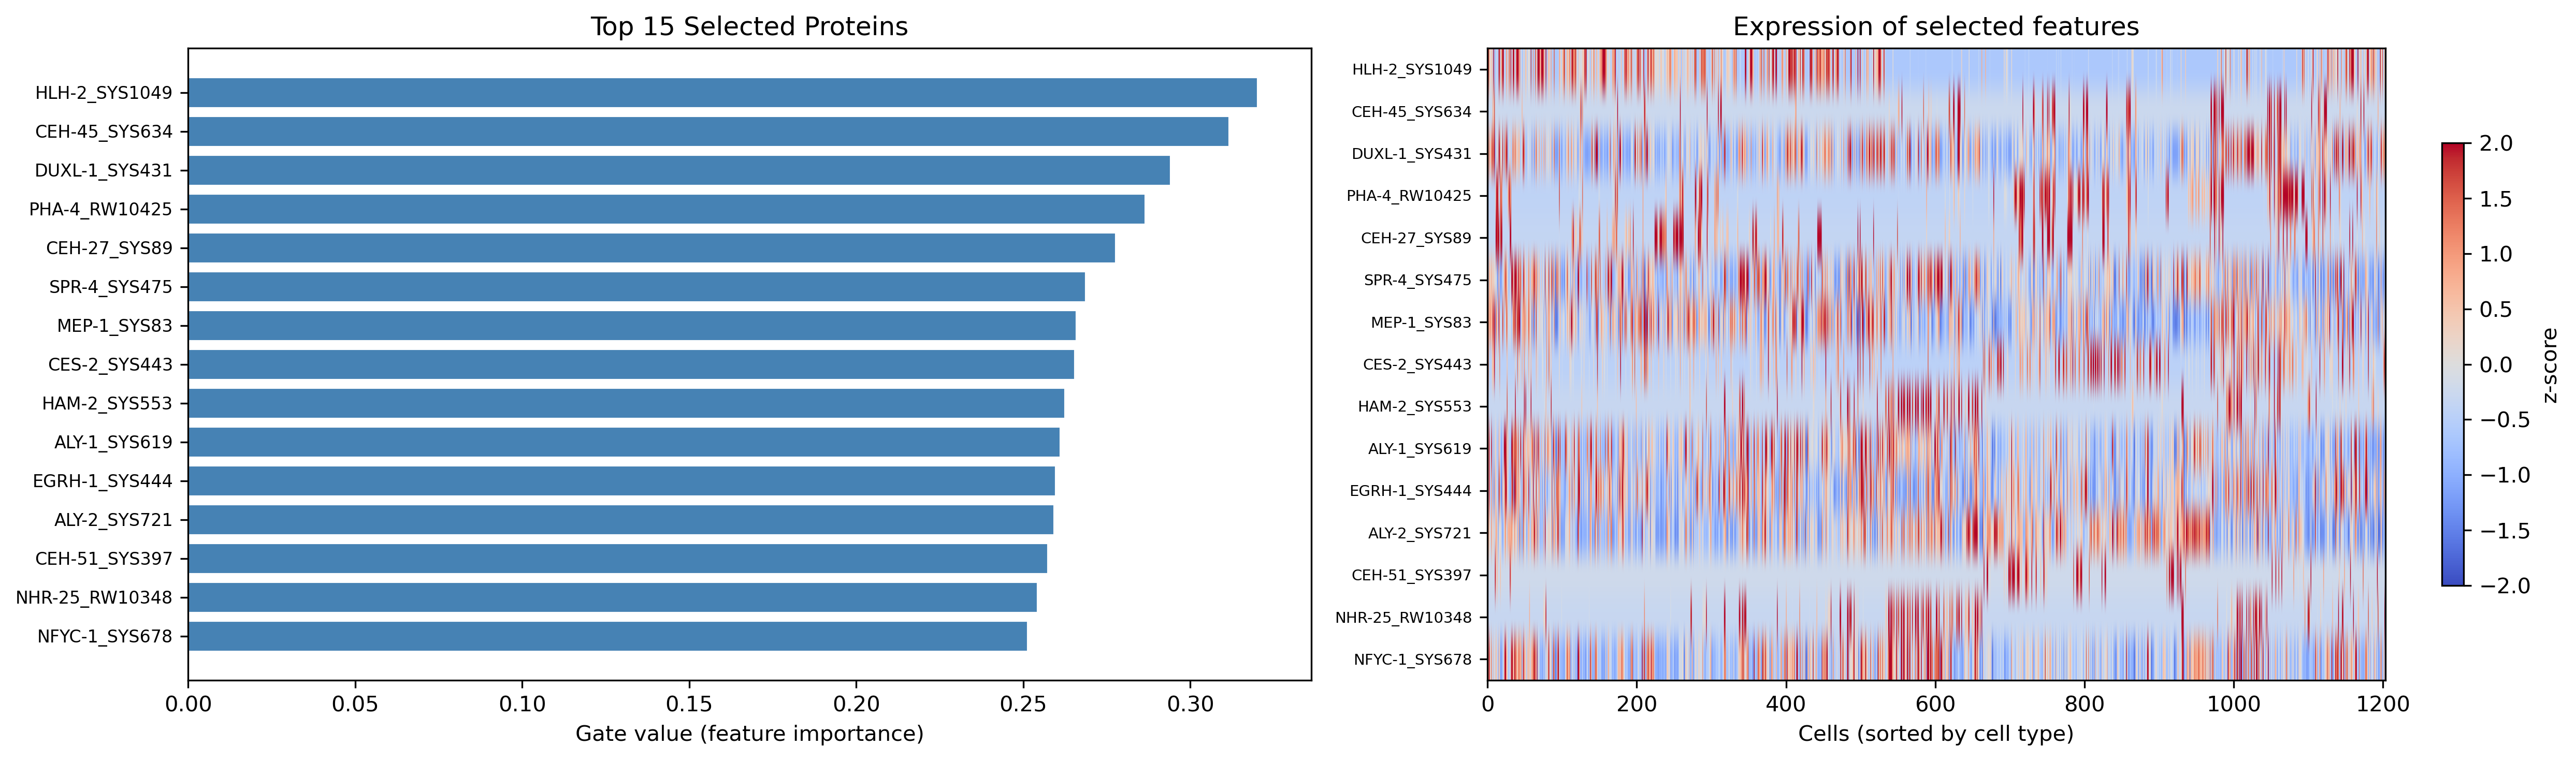

In [21]:

# ─── Feature Selection: top-N_SELECT features by gate value ──────────────────

top_features = feature_names[top_idx]
top_gates    = gate_vals[top_idx]

print(f"{'Rank':>4}  {'Feature':35s}  {'Gate':>6}")
print("-" * 50)
for rank, (name, g) in enumerate(zip(top_features, top_gates), 1):
    print(f"  {rank:2d}   {name:35s}  {g:.4f}")

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Bar chart of importance
ax = axes[0]
ax.barh(range(N_SELECT), top_gates[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(N_SELECT))
ax.set_yticklabels(top_features[::-1], fontsize=8)
ax.set_xlabel('Gate value (feature importance)')
ax.set_title(f'Top {N_SELECT} Selected Proteins')

# Heatmap: selected features × cells, sorted by true cell type
ax = axes[1]
cell_type_order = np.argsort(y.argmax(axis=1))
X_sel_plot = X[:, top_idx][cell_type_order]
im = ax.imshow(X_sel_plot.T, aspect='auto', cmap='coolwarm', vmin=-2, vmax=2)
ax.set_yticks(range(N_SELECT))
ax.set_yticklabels(top_features, fontsize=7)
ax.set_xlabel('Cells (sorted by cell type)')
ax.set_title('Expression of selected features')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.7)

plt.tight_layout()
plt.show()


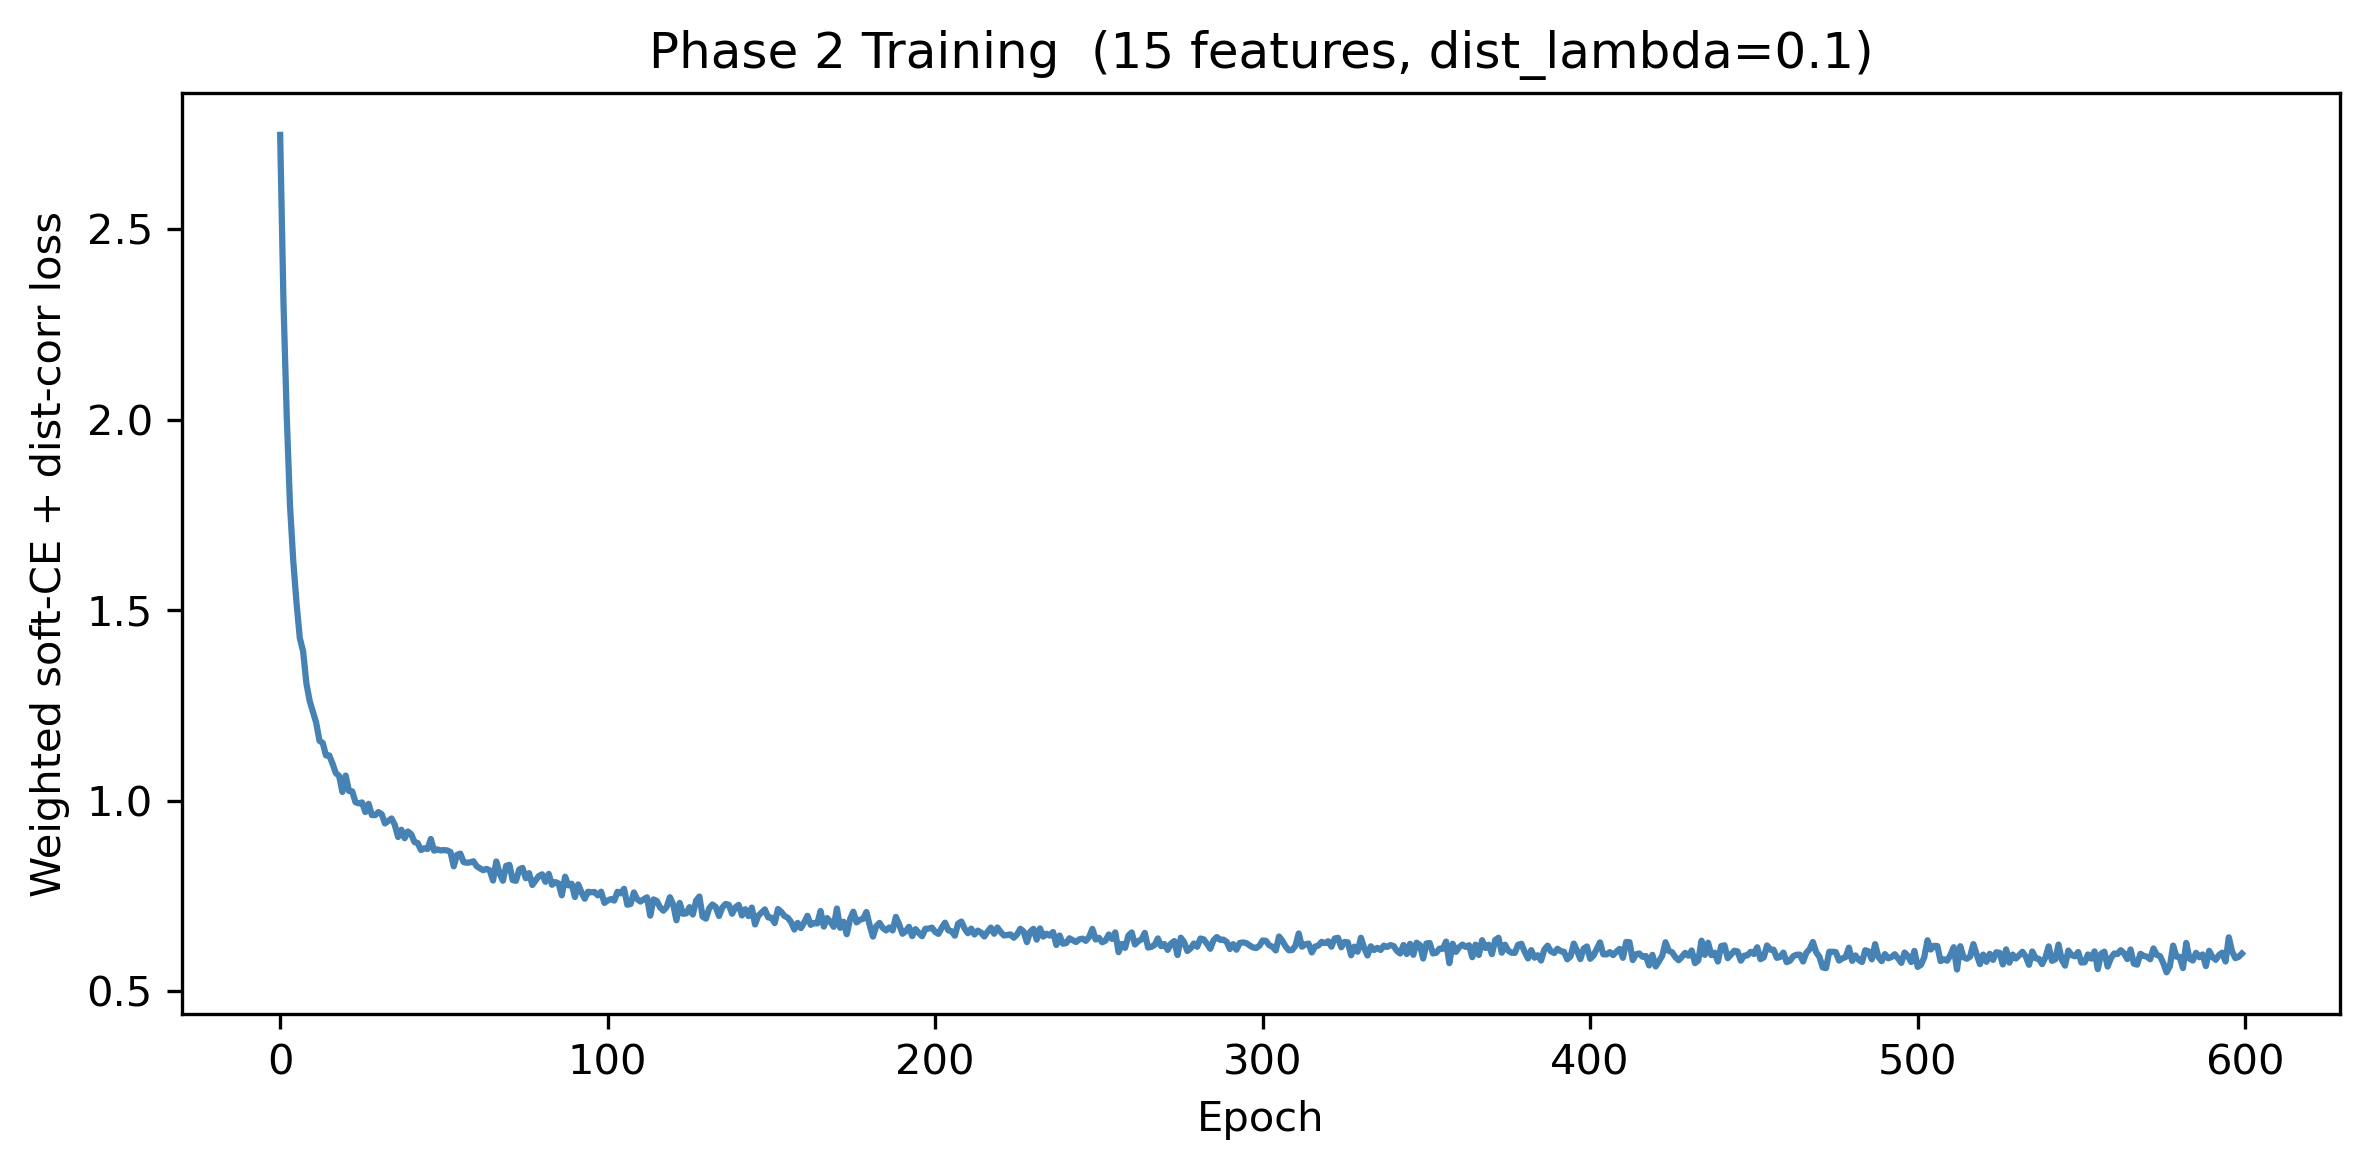


Final hard-label (terminal) accuracy : 0.9555
Final all-sample accuracy            : 0.8264

Embedding shape : (1204, 32)  (n_samples × embed_dim)


In [22]:

# ─── Phase 2: FocusedClassifier on selected features ─────────────────────────
#
# Why two phases instead of one?
# The one-pass SparseGateClassifier is trained on the full (gated) protein
# space.  Its embedding is excellent at separating cell types but correlates
# poorly with pairwise distances in the original expression space, because the
# high-dimensional backbone can learn a metric totally unrelated to input geometry.
#
# Training a smaller model on only the N_SELECT features constrains the
# embedding to be a smooth function of that low-dimensional subspace, which
# naturally preserves much of the original distance structure.
#
# The dist_lambda term reinforces this: it adds -Pearson(d_emb, d_input) as a
# per-batch loss, directly maximising correlation between pairwise distances in
# embedding space and selected-feature space.
#
# Tuning dist_lambda:
#   0    → pure classification  (embedding may drift from expression space)
#   0.1  → good balance         (default)
#   >0.5 → distances well preserved but type-separation may weaken

from feature_selection import train_focused

DIST_LAMBDA    = 0.1   # set to 0 to disable distance-preservation term
N_EPOCHS_P2    = 600
P2_HIDDEN_DIMS = (64, 32)   # smaller arch; last element = embedding dim

model_final, embeddings, losses_p2 = train_focused(
    X_sel, y, sample_weights_v2,
    hidden_dims = P2_HIDDEN_DIMS,
    dropout     = 0.2,
    n_epochs    = N_EPOCHS_P2,
    batch_size  = 64,
    seed        = 42,
    device      = str(device),
    dist_lambda = DIST_LAMBDA,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_p2, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted soft-CE + dist-corr loss')
ax.set_title(f'Phase 2 Training  ({N_SELECT} features, dist_lambda={DIST_LAMBDA})')
plt.tight_layout()
plt.show()

final_acc = eval_accuracy(model_final, X_sel_t, y_t, term_t, device)
all_acc   = eval_accuracy(model_final, X_sel_t, y_t, np.ones(len(y), dtype=bool), device)
print(f"\nFinal hard-label (terminal) accuracy : {final_acc:.4f}")
print(f"Final all-sample accuracy            : {all_acc:.4f}")
print(f"\nEmbedding shape : {embeddings.shape}  (n_samples × embed_dim)")


Hard-label accuracy  : 0.9555
All-sample accuracy  : 0.8264

Cell type                         Acc  n
---------------------------------------------
  sheath                        1.000  22
  socket                        1.000  18
  muscle                        1.000  110
  rectal                        1.000  2
  tail                          1.000  2
  valve                         1.000  8
  intestine                     1.000  2
  mesoderm                      1.000  1
  repro                         1.000  2
  neuron                        0.994  167
  hypoderm                      0.980  51
  other                         0.889  9
  programmed_death              0.865  74
  epithelium                    0.769  13
  excretory                     0.750  4
  marginal                      0.444  9


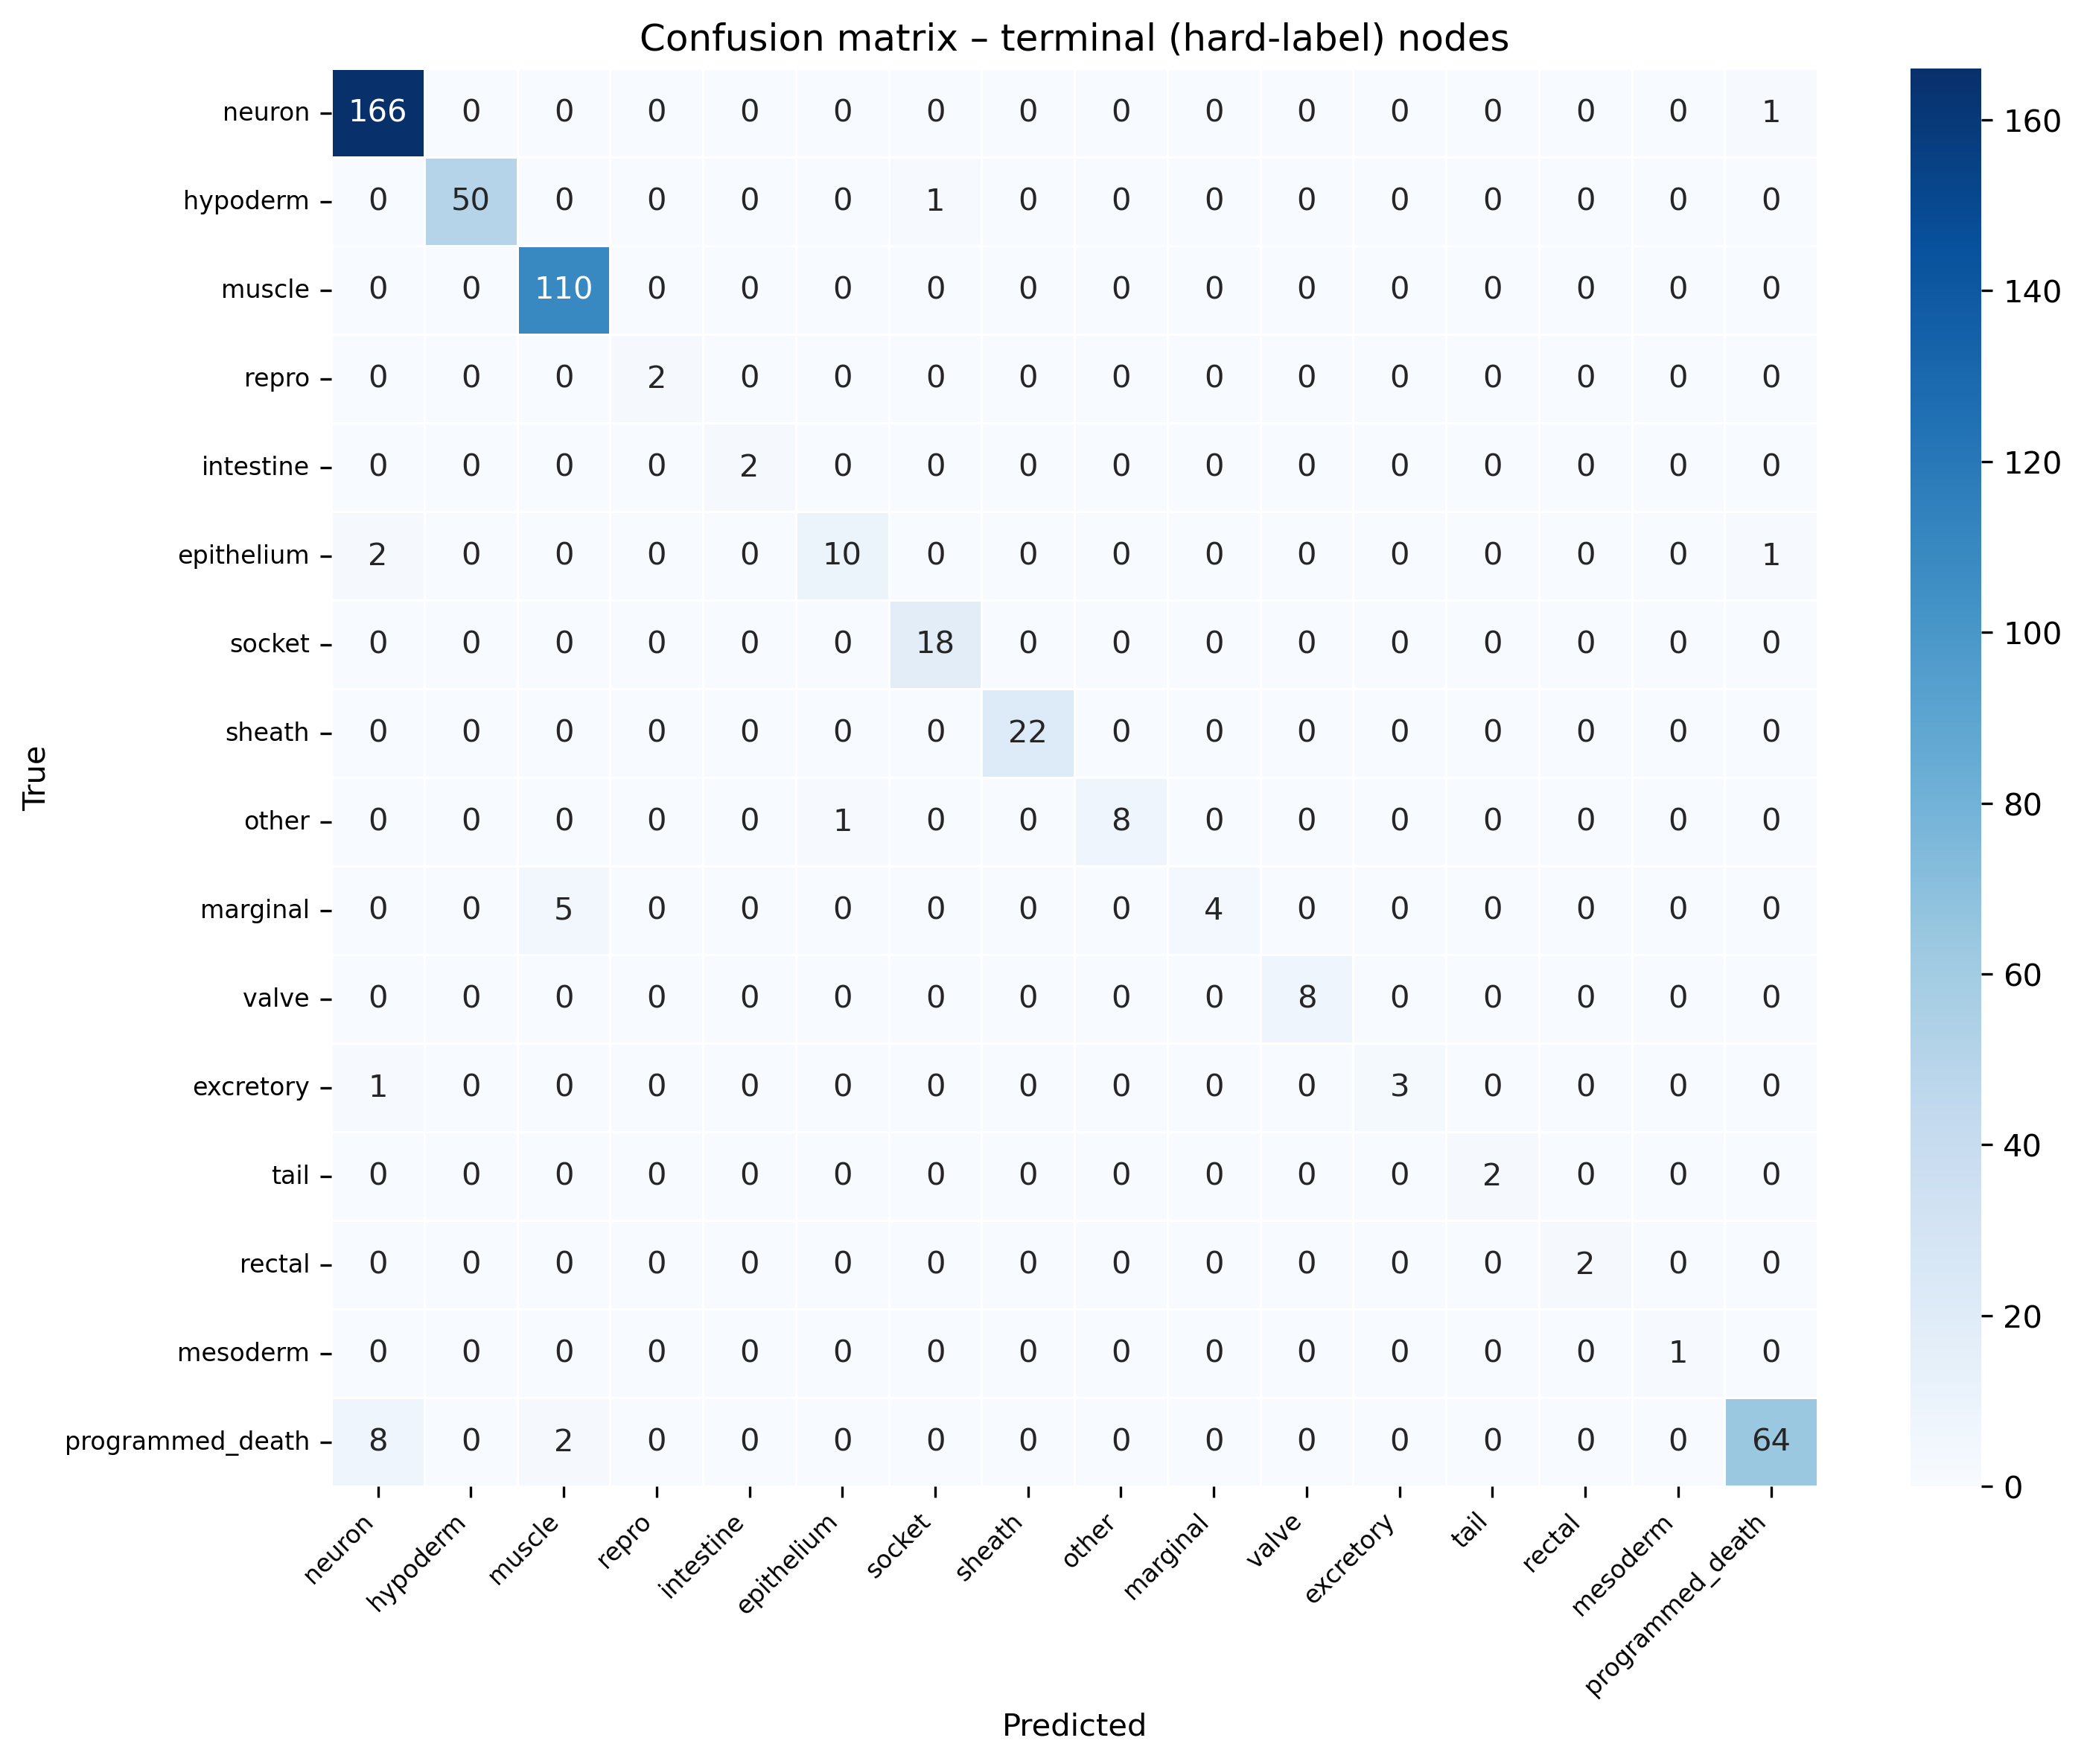

In [23]:

# ─── Evaluation: confusion matrix on hard-label (terminal) nodes ──────────────

model_final.eval()
with torch.no_grad():
    logits_all, _ = model_final(X_sel_t.to(device))
    probs_all = F.softmax(logits_all, dim=-1).cpu().numpy()

preds_all   = probs_all.argmax(axis=1)
targets_all = y.argmax(axis=1)

term_preds   = preds_all[terminal_mask]
term_targets = targets_all[terminal_mask]

print(f"Hard-label accuracy  : {(term_preds == term_targets).mean():.4f}")
print(f"All-sample accuracy  : {(preds_all == targets_all).mean():.4f}\n")

# Per-cell-type breakdown
per_type = defaultdict(list)
for p, t in zip(term_preds, term_targets):
    per_type[cell_types[t]].append(p == t)

print(f"{'Cell type':30s}  {'Acc':>5}  n")
print("-" * 45)
for ct, vals in sorted(per_type.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {ct:28s}  {np.mean(vals):.3f}  {len(vals)}")

# Confusion matrix
present_types = sorted(np.unique(term_targets).tolist())
conf = np.zeros((len(present_types), len(present_types)), dtype=int)
t2i  = {t: i for i, t in enumerate(present_types)}
for p, t in zip(term_preds, term_targets):
    if p in t2i:
        conf[t2i[t], t2i[p]] += 1

ct_labels = [cell_types[i] for i in present_types]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ct_labels, yticklabels=ct_labels, ax=ax,
            linewidths=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix – terminal (hard-label) nodes')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


Embedding matrix: (1204, 32)  (n_cells × embed_dim)
Cell names: ['ABa' 'ABal' 'ABala' 'ABalaa' 'ABalaaa'] ...


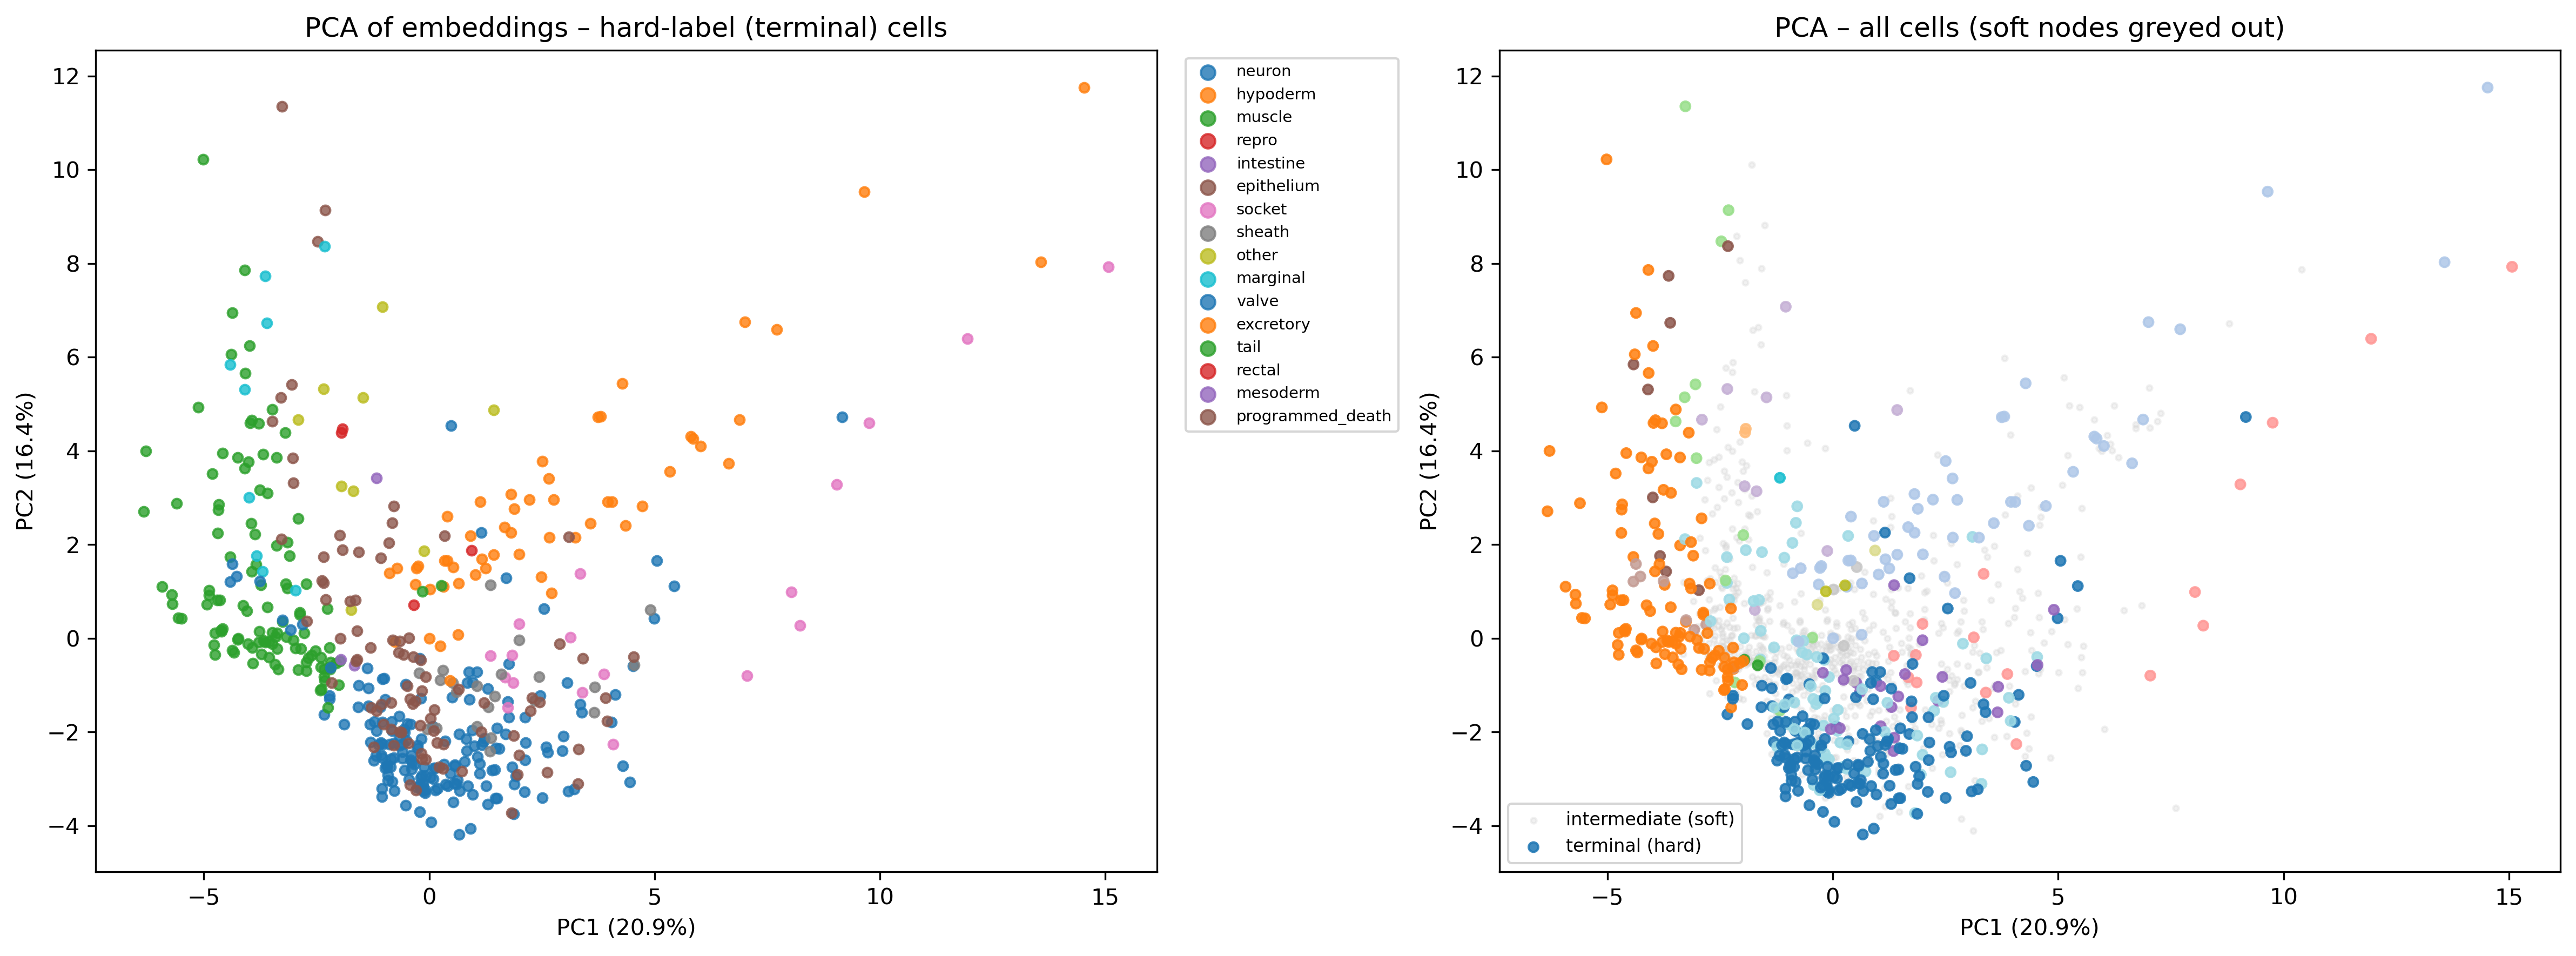

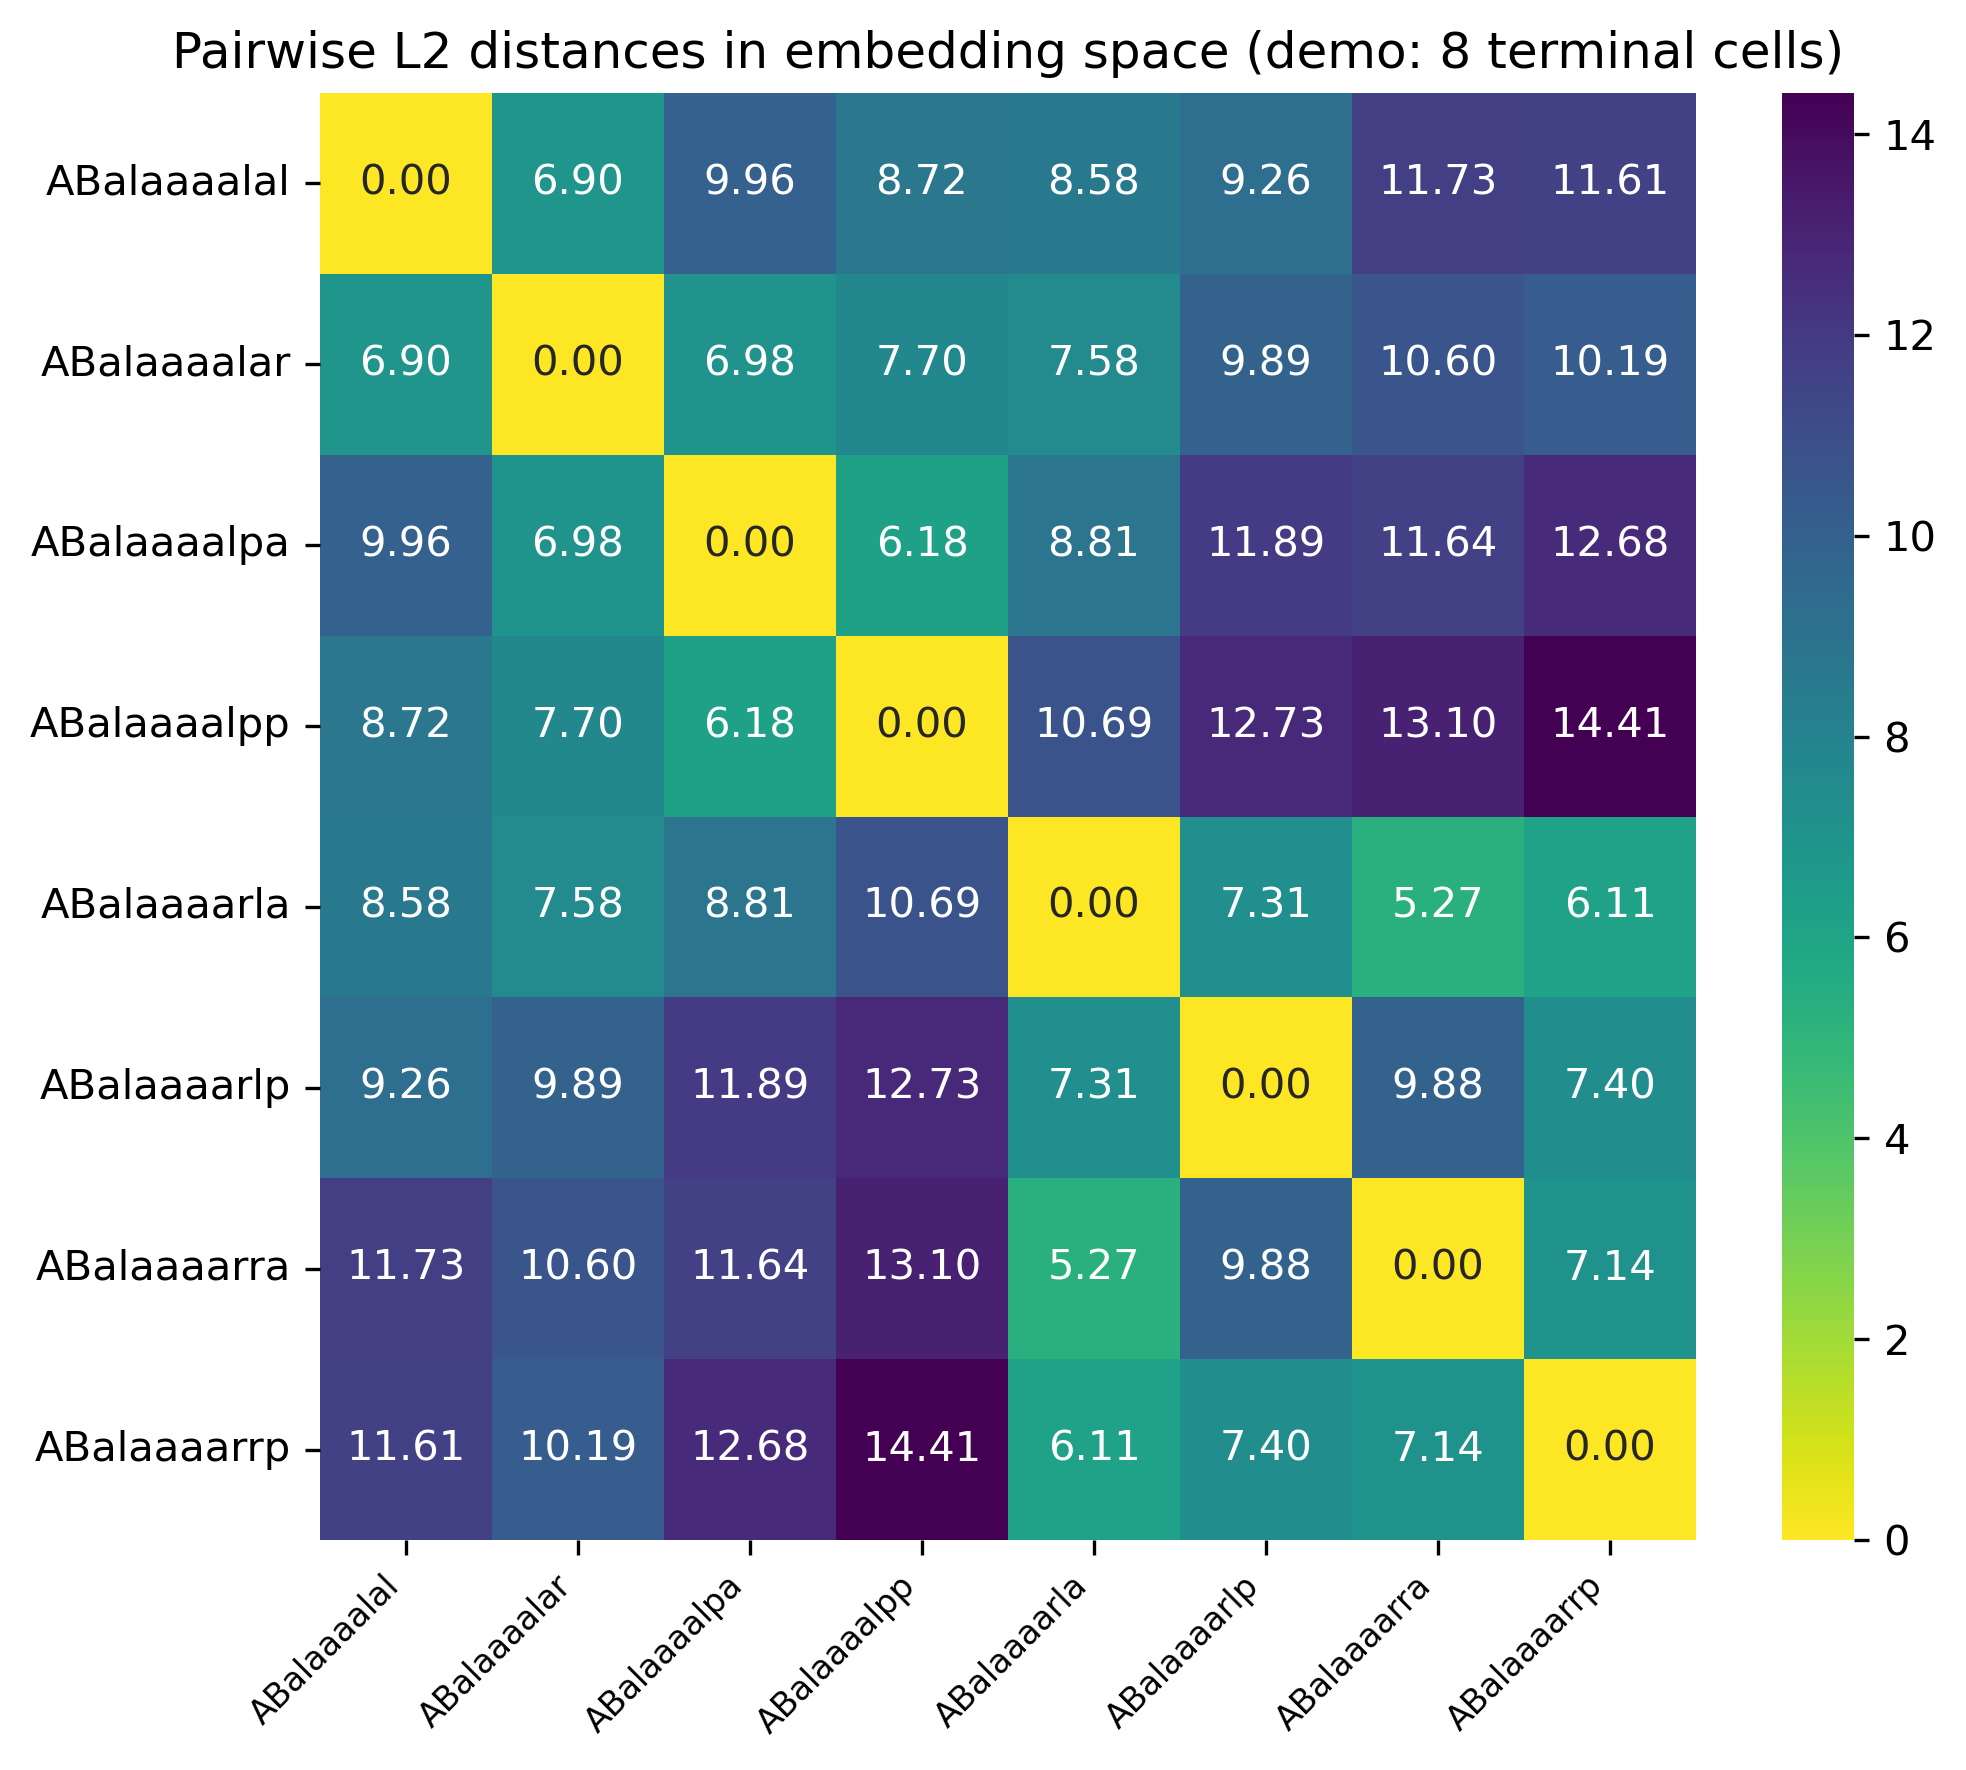


To compute all pairwise distances:
  dist_all    = cdist(embeddings, embeddings, metric='euclidean')
  dist_cosine = cdist(embeddings, embeddings, metric='cosine')

Embedding array: `embeddings`  shape=(1204, 32)
Cell names     : `cell_names`  n=1204


In [24]:

# ─── Embeddings for downstream distance analysis ─────────────────────────────
#
# `embeddings` (n_samples × embed_dim) is already produced by train_one_pass().
# The penultimate layer of the one-pass SparseGateClassifier is used directly —
# no separate FocusedClassifier needed.
#
# Properties:
#   • Trained with soft-label supervision → intermediate nodes land between
#     their descendant terminal nodes in embedding space.
#   • Weighted training → distances among terminal nodes are most reliable.
#   • embed_dim = last element of best_config['hidden_dims'] (flexible).

cell_names = np.array([map_names(n) for n in protein_exp_zscore.columns])

print(f"Embedding matrix: {embeddings.shape}  (n_cells × embed_dim)")
print(f"Cell names: {cell_names[:5]} ...")

# ── PCA visualisation ─────────────────────────────────────────────────────────
pca    = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
ct_idx = y.argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hard-label nodes coloured by cell type
ax = axes[0]
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & terminal_mask
    if mask_ct.sum() > 0:
        ax.scatter(emb_2d[mask_ct, 0], emb_2d[mask_ct, 1],
                   label=ct, s=18, alpha=0.8)
ax.set_title('PCA of embeddings – hard-label (terminal) cells')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

# All cells: soft nodes in grey, hard nodes coloured
ax = axes[1]
ax.scatter(emb_2d[~terminal_mask, 0], emb_2d[~terminal_mask, 1],
           c='lightgray', s=6, alpha=0.3, label='intermediate (soft)')
scatter = ax.scatter(emb_2d[terminal_mask, 0], emb_2d[terminal_mask, 1],
                     c=ct_idx[terminal_mask], cmap='tab20', s=18, alpha=0.85,
                     label='terminal (hard)')
ax.set_title('PCA – all cells (soft nodes greyed out)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Example: pairwise L2 distances among a handful of terminal cells ──────────
from scipy.spatial.distance import cdist

demo_idx   = np.where(terminal_mask)[0][:8]
demo_names = cell_names[demo_idx]
demo_emb   = embeddings[demo_idx]

dist_mat = cdist(demo_emb, demo_emb, metric='euclidean')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='viridis_r',
            xticklabels=demo_names, yticklabels=demo_names, ax=ax)
ax.set_title('Pairwise L2 distances in embedding space (demo: 8 terminal cells)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTo compute all pairwise distances:")
print("  dist_all    = cdist(embeddings, embeddings, metric='euclidean')")
print("  dist_cosine = cdist(embeddings, embeddings, metric='cosine')")
print(f"\nEmbedding array: `embeddings`  shape={embeddings.shape}")
print(f"Cell names     : `cell_names`  n={len(cell_names)}")


Total terminal-sibling pairs in data: 209
  Same cell type : 105
  Diff cell type : 104

Same-type sibling distance:  mean=3.409  median=3.201  std=1.586
Diff-type sibling distance:  mean=5.078  median=4.965  std=1.891

Mann-Whitney U (same < diff): U=2534, p=1.10e-11
KS test (distributions differ): D=0.455, p=1.98e-10


/tmp/ipykernel_428967/1782416390.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),


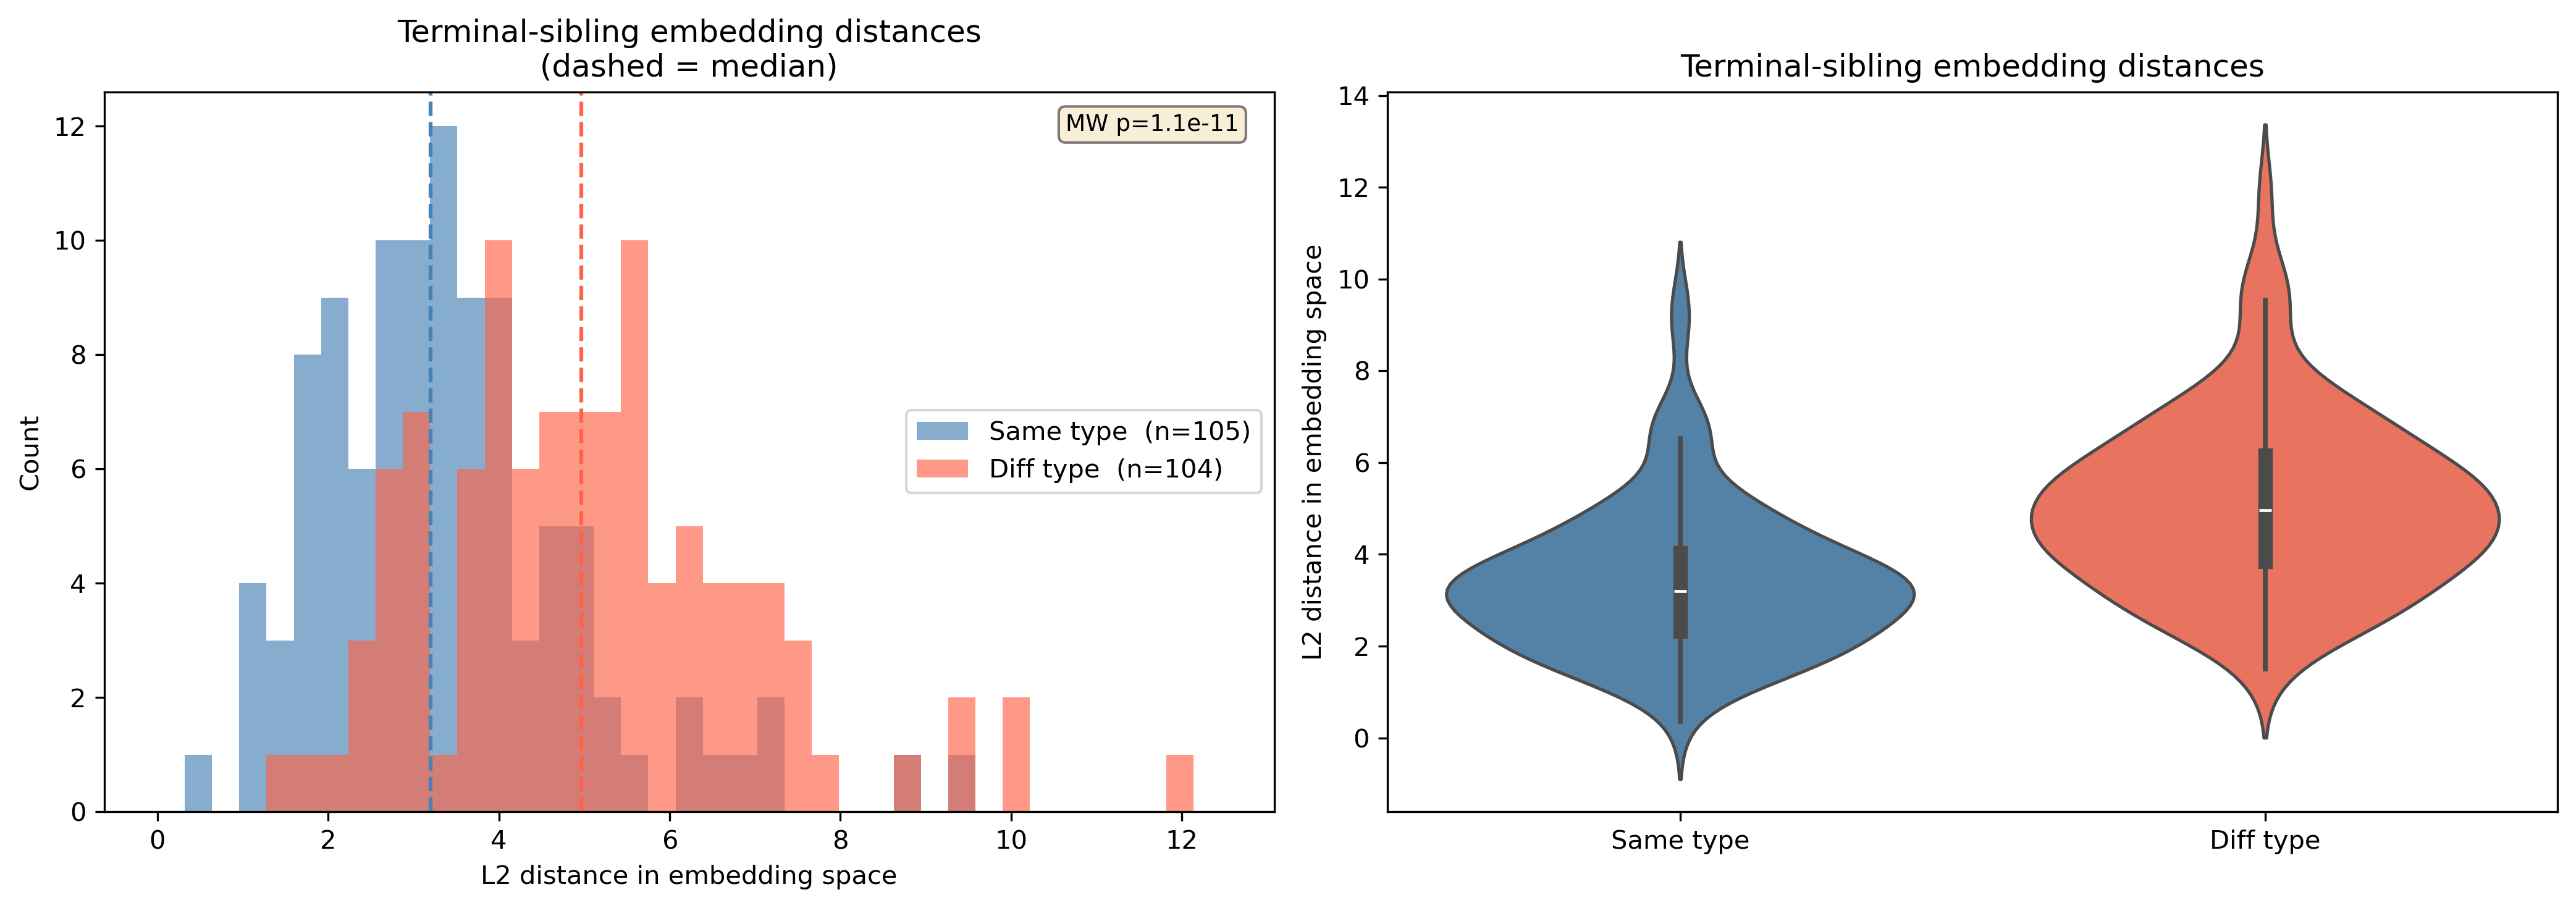


Same-type sibling distances by cell type:
  Type                              n    mean   median
  ----------------------------------------------------
  repro                             1   0.360    0.360
  valve                             2   2.006    2.006
  muscle                           38   3.059    3.009
  neuron                           42   3.423    3.300
  hypoderm                         17   3.896    3.613
  other                             2   4.379    4.379
  sheath                            2   5.710    5.710
  socket                            1   7.111    7.111


In [33]:

# ─── Sanity check: embedding distance for terminal siblings ──────────────────
#
# Hypothesis: same-type sibling pairs should have SMALLER embedding distance
# than different-type sibling pairs, because the classifier was trained to
# separate cell types.
#
# "Terminal siblings" = two terminal nodes that share the same direct parent.

# ── 1. Build parent→children map from the lineage tree ────────────────────────
children_dict_lin = defaultdict(list)   # parent_name → [child_names]
parent_dict_lin   = {}                  # child_name  → parent_name

def build_family(node, parent_name=None):
    name = map_names(node["did"])
    if parent_name is not None:
        parent_dict_lin[name] = parent_name
        children_dict_lin[parent_name].append(name)
    for child in node.get("children", []):
        build_family(child, name)

build_family(lineage_data)

# ── 2. Collect terminal-sibling pairs that are in the protein_exp data ─────────
# cell_names is the array of mapped cell names from protein_exp columns
cell_name_to_idx = {name: i for i, name in enumerate(cell_names)}
terminal_set     = set(cell_names[terminal_mask])   # terminal nodes present in data

sibling_pairs = []   # list of (nameA, nameB, same_type: bool)

for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    # All pairs among terminal children of this parent
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            sibling_pairs.append((a, b, type_a == type_b))

same_pairs = [(a, b) for a, b, s in sibling_pairs if     s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]
print(f"Total terminal-sibling pairs in data: {len(sibling_pairs)}")
print(f"  Same cell type : {len(same_pairs)}")
print(f"  Diff cell type : {len(diff_pairs)}")

# ── 3. Compute embedding distances ────────────────────────────────────────────
def pair_distance(a, b):
    ia, ib = cell_name_to_idx[a], cell_name_to_idx[b]
    return float(np.linalg.norm(embeddings[ia] - embeddings[ib]))

same_dists = np.array([pair_distance(a, b) for a, b in same_pairs])
diff_dists = np.array([pair_distance(a, b) for a, b in diff_pairs])

print(f"\nSame-type sibling distance:  mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}  std={same_dists.std():.3f}")
print(f"Diff-type sibling distance:  mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}  std={diff_dists.std():.3f}")

# Mann-Whitney U test (non-parametric, no normality assumption)
from scipy.stats import mannwhitneyu, ks_2samp
u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')
ks_stat, p_ks = ks_2samp(same_dists, diff_dists)
print(f"\nMann-Whitney U (same < diff): U={u_stat:.0f}, p={p_mw:.2e}")
print(f"KS test (distributions differ): D={ks_stat:.3f}, p={p_ks:.2e}")

# ── 4. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
ax = axes[0]
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
ax.hist(same_dists, bins=bins, alpha=0.65, color='steelblue',  label=f'Same type  (n={len(same_dists)})')
ax.hist(diff_dists, bins=bins, alpha=0.65, color='tomato',     label=f'Diff type  (n={len(diff_dists)})')
ax.axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(np.median(diff_dists), color='tomato',    linestyle='--', linewidth=1.5)
ax.set_xlabel('L2 distance in embedding space')
ax.set_ylabel('Count')
ax.set_title('Terminal-sibling embedding distances\n(dashed = median)')
ax.legend()
ax.text(0.97, 0.97, f'MW p={p_mw:.1e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# violinplot
ax = axes[1]
sns.violinplot(x=['Same type'] * len(same_dists) + ['Diff type'] * len(diff_dists),
               y=np.concatenate([same_dists, diff_dists]),
               palette=['steelblue', 'tomato'], ax=ax)
ax.set_ylabel('L2 distance in embedding space')
ax.set_title('Terminal-sibling embedding distances')

plt.tight_layout()
plt.show()

# ── 5. Per-type breakdown for same-type pairs ─────────────────────────────────
type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        type_pair_dists[t].append(pair_distance(a, b))

print("\nSame-type sibling distances by cell type:")
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print("  " + "-" * 52)
for t, dists in sorted(type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")


Original 15-feature space:
  Same-type sibling distance: mean=1.959  median=1.741  std=1.020
  Diff-type sibling distance: mean=2.530  median=2.438  std=1.068
  Mann-Whitney U (same < diff): U=3621, p=1.30e-05
  KS test (distributions differ): D=0.291, p=2.39e-04
  Median ratio (diff/same): 1.400
  Cohen's d: 0.544
  AUC-like separation: 0.668

Distance correlation (Phase 2 embedding vs. selected-feature space, terminal cells only):
  Pearson  r = 0.9053
  Spearman r = 0.8885


,space,same_median,diff_median,median_ratio,cohen_d,auc_like,mw_pvalue
0,Selected 15 features,1.7406,2.4375,1.4004,0.5441,0.6684,0.0
1,32D embedding,3.2009,4.9651,1.5511,0.9521,0.7679,0.0


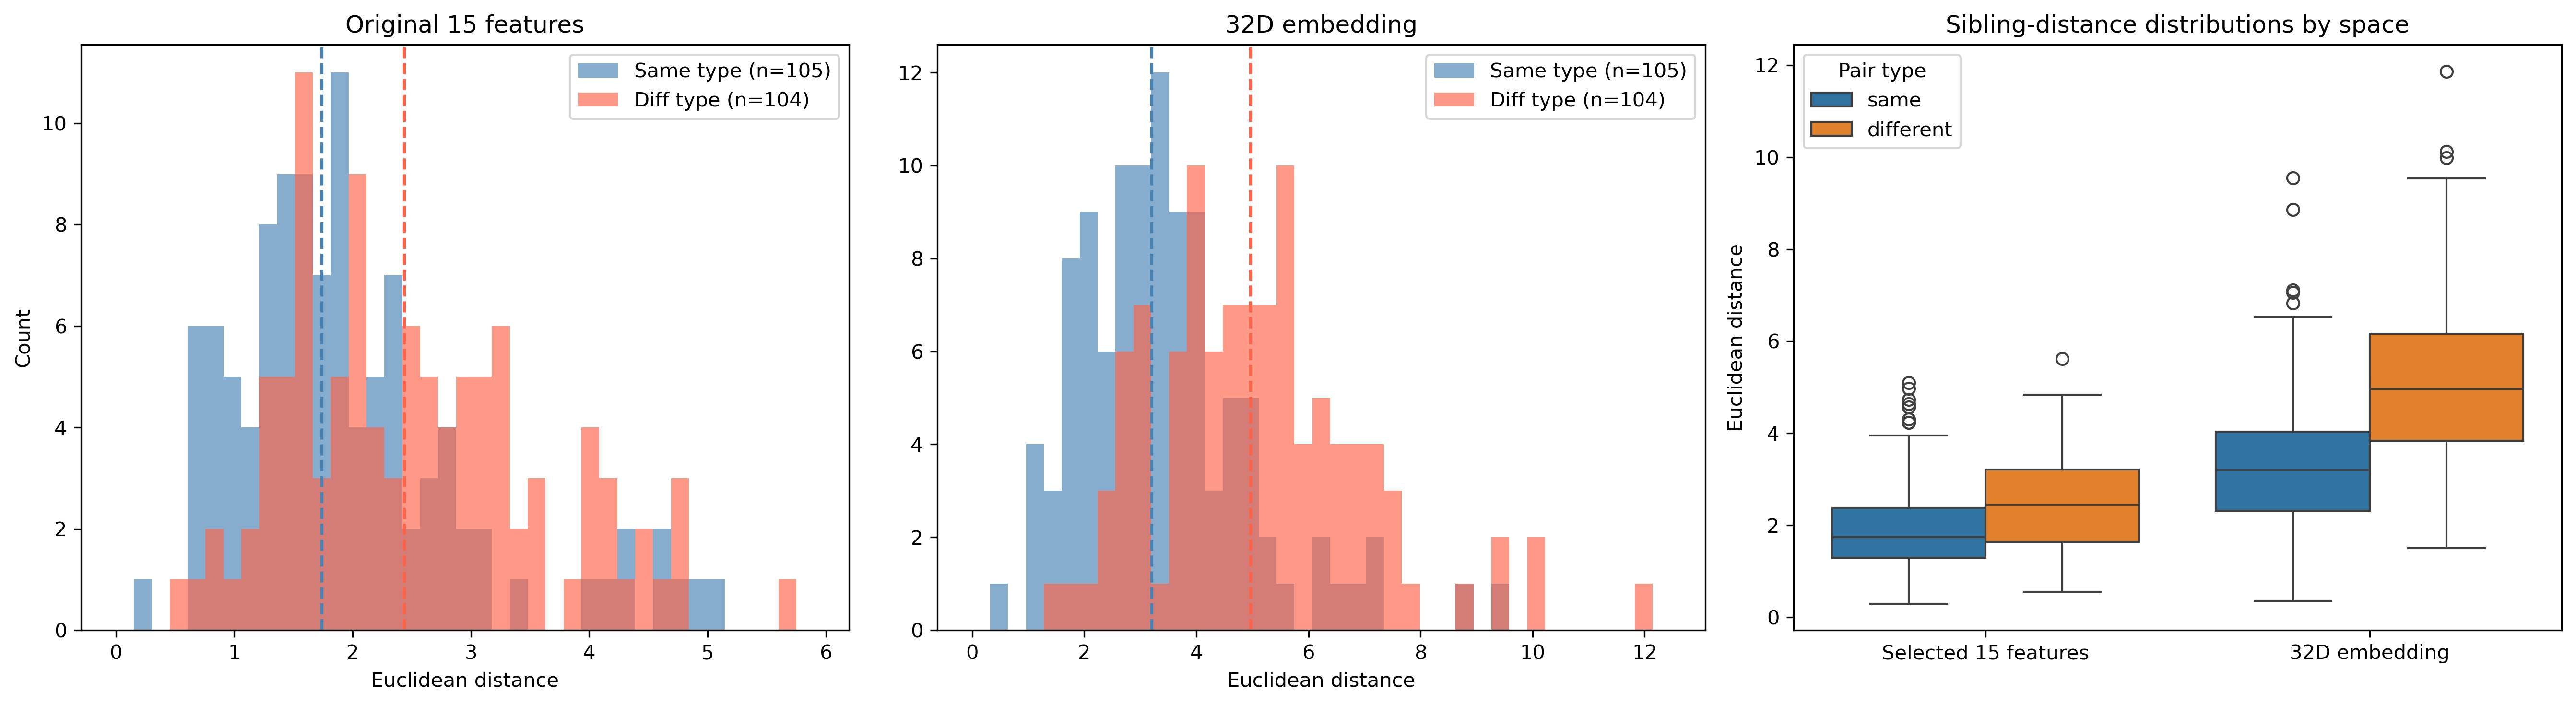


Same-type sibling distances by cell type in the original 15-feature space:
  Type                              n    mean   median
  ----------------------------------------------------
  repro                             1   0.297    0.297
  valve                             2   1.231    1.231
  neuron                           42   1.751    1.563
  muscle                           38   1.853    1.723
  hypoderm                         17   2.474    2.291
  other                             2   2.480    2.480
  socket                            1   2.782    2.782
  sheath                            2   4.602    4.602

Interpretation: the 32D embedding sharpens sibling-type separation beyond what is already present in the raw 15 selected features.


In [26]:

# ─── Sanity check: sibling distances in the original selected-feature space ─────
#
# Question: do the N_SELECT selected protein features already separate
# same-type vs different-type terminal siblings in a way similar to the
# learned embedding?  And does the dist_lambda regularisation in Phase 2
# improve the correlation between the two spaces?

from scipy.stats import mannwhitneyu, ks_2samp

def pair_distance_in_space(a, b, representation, name_to_idx):
    ia, ib = name_to_idx[a], name_to_idx[b]
    return float(np.linalg.norm(representation[ia] - representation[ib]))

selected_feature_repr = X_sel
selected_same_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in same_pairs
])
selected_diff_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in diff_pairs
])

u_feat, p_feat     = mannwhitneyu(selected_same_dists, selected_diff_dists, alternative='less')
ks_feat, p_ks_feat = ks_2samp(selected_same_dists, selected_diff_dists)

def separation_summary(same_dists, diff_dists, u_stat):
    n_same = len(same_dists)
    n_diff = len(diff_dists)
    pooled_std = np.sqrt(
        ((n_same - 1) * same_dists.std(ddof=1) ** 2 + (n_diff - 1) * diff_dists.std(ddof=1) ** 2)
        / (n_same + n_diff - 2)
    )
    cohen_d = (diff_dists.mean() - same_dists.mean()) / pooled_std
    auc = 1.0 - (u_stat / (n_same * n_diff))
    return {
        'same_mean': same_dists.mean(),
        'same_median': np.median(same_dists),
        'diff_mean': diff_dists.mean(),
        'diff_median': np.median(diff_dists),
        'median_ratio': np.median(diff_dists) / np.median(same_dists),
        'cohen_d': cohen_d,
        'auc_like': auc,
    }

embed_dim_label   = f'{embeddings.shape[1]}D embedding'
embedding_summary = separation_summary(same_dists, diff_dists, u_stat)
feature_summary   = separation_summary(selected_same_dists, selected_diff_dists, u_feat)

print(f'Original {N_SELECT}-feature space:')
print(f"  Same-type sibling distance: mean={feature_summary['same_mean']:.3f}  median={feature_summary['same_median']:.3f}  std={selected_same_dists.std():.3f}")
print(f"  Diff-type sibling distance: mean={feature_summary['diff_mean']:.3f}  median={feature_summary['diff_median']:.3f}  std={selected_diff_dists.std():.3f}")
print(f"  Mann-Whitney U (same < diff): U={u_feat:.0f}, p={p_feat:.2e}")
print(f"  KS test (distributions differ): D={ks_feat:.3f}, p={p_ks_feat:.2e}")
print(f"  Median ratio (diff/same): {feature_summary['median_ratio']:.3f}")
print(f"  Cohen's d: {feature_summary['cohen_d']:.3f}")
print(f"  AUC-like separation: {feature_summary['auc_like']:.3f}")

# ── Mantel-style correlation: how well do embedding distances track feature distances? ──
all_term_idx   = np.where(terminal_mask)[0]
term_feat_dists = squareform(pdist(X_sel[all_term_idx], metric='euclidean'))
term_emb_dists  = squareform(pdist(embeddings[all_term_idx], metric='euclidean'))
upper_tri = np.triu_indices(len(all_term_idx), k=1)
from scipy.stats import pearsonr, spearmanr as sp_r
r_pearson, _  = pearsonr( term_feat_dists[upper_tri], term_emb_dists[upper_tri])
r_spearman, _ = sp_r(     term_feat_dists[upper_tri], term_emb_dists[upper_tri])
print(f"\nDistance correlation (Phase 2 embedding vs. selected-feature space, terminal cells only):")
print(f"  Pearson  r = {r_pearson:.4f}")
print(f"  Spearman r = {r_spearman:.4f}")

comparison_df = pd.DataFrame(
    [
        {
            'space': f'Selected {N_SELECT} features',
            'same_median': feature_summary['same_median'],
            'diff_median': feature_summary['diff_median'],
            'median_ratio': feature_summary['median_ratio'],
            'cohen_d': feature_summary['cohen_d'],
            'auc_like': feature_summary['auc_like'],
            'mw_pvalue': p_feat,
        },
        {
            'space': embed_dim_label,
            'same_median': embedding_summary['same_median'],
            'diff_median': embedding_summary['diff_median'],
            'median_ratio': embedding_summary['median_ratio'],
            'cohen_d': embedding_summary['cohen_d'],
            'auc_like': embedding_summary['auc_like'],
            'mw_pvalue': p_mw,
        },
    ]
)
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins_feat = np.linspace(
    0, max(selected_same_dists.max(), selected_diff_dists.max()) * 1.05, 40
)
axes[0].hist(selected_same_dists, bins=bins_feat, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(selected_same_dists)})')
axes[0].hist(selected_diff_dists, bins=bins_feat, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(selected_diff_dists)})')
axes[0].axvline(np.median(selected_same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(np.median(selected_diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Original {N_SELECT} features')
axes[0].set_xlabel('Euclidean distance')
axes[0].set_ylabel('Count')
axes[0].legend()

bins_emb = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
axes[1].hist(same_dists, bins=bins_emb, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(same_dists)})')
axes[1].hist(diff_dists, bins=bins_emb, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(diff_dists)})')
axes[1].axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(np.median(diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title(embed_dim_label)
axes[1].set_xlabel('Euclidean distance')
axes[1].legend()

comparison_long = pd.DataFrame({
    'distance': np.concatenate([selected_same_dists, selected_diff_dists, same_dists, diff_dists]),
    'pair_type': (['same'] * len(selected_same_dists) + ['different'] * len(selected_diff_dists) +
                  ['same'] * len(same_dists) + ['different'] * len(diff_dists)),
    'space': ([f'Selected {N_SELECT} features'] * (len(selected_same_dists) + len(selected_diff_dists)) +
              [embed_dim_label] * (len(same_dists) + len(diff_dists)))
})
sns.boxplot(data=comparison_long, x='space', y='distance', hue='pair_type', ax=axes[2])
axes[2].set_title('Sibling-distance distributions by space')
axes[2].set_xlabel('')
axes[2].set_ylabel('Euclidean distance')
axes[2].legend(title='Pair type')

plt.tight_layout()
plt.show()

feature_type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        feature_type_pair_dists[t].append(
            pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
        )

print(f'\nSame-type sibling distances by cell type in the original {N_SELECT}-feature space:')
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print('  ' + '-' * 52)
for t, dists in sorted(feature_type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")

if feature_summary['auc_like'] >= embedding_summary['auc_like'] - 0.02:
    print(f'\nInterpretation: the original {N_SELECT}-feature space preserves most of the sibling-type separation signal seen in the learned embedding.')
else:
    print(f'\nInterpretation: the {embed_dim_label} sharpens sibling-type separation beyond what is already present in the raw {N_SELECT} selected features.')


In [27]:
top_features     = feature_names[top_idx]
trimmed_proteins = [f.rsplit('_', 1)[0] for f in top_features]
trimmed_proteins

['HLH-2',
 'CEH-45',
 'DUXL-1',
 'PHA-4',
 'CEH-27',
 'SPR-4',
 'MEP-1',
 'CES-2',
 'HAM-2',
 'ALY-1',
 'EGRH-1',
 'ALY-2',
 'CEH-51',
 'NHR-25',
 'NFYC-1']

In [28]:

# Save embeddings and selected protein names to disk
import os

out_dir  = './data/protein/aggregated_all/'
os.makedirs(out_dir, exist_ok=True)

embed_dim = embeddings.shape[1]
emb_cols  = [f'emb_{i}' for i in range(embed_dim)]
emb_df    = pd.DataFrame(embeddings, index=cell_names, columns=emb_cols)
emb_df.index.name = 'cell_name'

emb_filename = f'embeddings_{embed_dim}d.csv'
emb_df.to_csv(os.path.join(out_dir, emb_filename))

# top_features: full feature names from protein_exp_zscore index
top_features     = feature_names[top_idx]
trimmed_proteins = [f.rsplit('_', 1)[0] for f in top_features]

pd.Series(trimmed_proteins).to_csv(
    os.path.join(out_dir, 'nn_selected_proteins_rev.tsv'),
    sep='\t', index=False, header=False,
)

print(f"Saved embeddings ({embed_dim}D) → {os.path.join(out_dir, emb_filename)}")
print(f"Saved selected proteins        → {os.path.join(out_dir, 'nn_selected_proteins_rev.tsv')}")
print(f"Selected proteins: {trimmed_proteins}")


Saved embeddings (32D) → ./data/protein/aggregated_all/embeddings_32d.csv
Saved selected proteins        → ./data/protein/aggregated_all/nn_selected_proteins_rev.tsv
Selected proteins: ['HLH-2', 'CEH-45', 'DUXL-1', 'PHA-4', 'CEH-27', 'SPR-4', 'MEP-1', 'CES-2', 'HAM-2', 'ALY-1', 'EGRH-1', 'ALY-2', 'CEH-51', 'NHR-25', 'NFYC-1']


In [27]:
tissue_specific_tfs = pd.read_csv('data/protein/aggregated_all/tissue_specific_tf.tsv', sep='\t', header=None, index_col=0).index.tolist()
tissue_specific_selected_proteins = list(set(tissue_specific_tfs).intersection(set(trimmed_proteins)))

In [28]:
# a new X_tissue_specific from the tissue_specific_selected_proteins
tissue_specific_indices = [i for i, f in enumerate(feature_names) if f.rsplit('_', 1)[0] in tissue_specific_selected_proteins]
X_tissue_specific = X[:, tissue_specific_indices]

In [29]:
selected_feature_repr = X_tissue_specific
selected_same_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in same_pairs
])
selected_diff_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in diff_pairs
])

u_feat, p_feat = mannwhitneyu(selected_same_dists, selected_diff_dists, alternative='less')
ks_feat, p_ks_feat = ks_2samp(selected_same_dists, selected_diff_dists)
feature_summary = separation_summary(selected_same_dists, selected_diff_dists, u_feat)
print('Tissue-specific selected features:')
print(f"  Same-type sibling distance: mean={feature_summary['same_mean']:.3f}  median={feature_summary['same_median']:.3f}  std={selected_same_dists.std():.3f}")
print(f"  Diff-type sibling distance: mean={feature_summary['diff_mean']:.3f}  median={feature_summary['diff_median']:.3f}  std={selected_diff_dists.std():.3f}")
print(f"  Mann-Whitney U (same < diff): U={u_feat:.0f}, p={p_feat:.2e}")
print(f"  KS test (distributions differ): D={ks_feat:.3f}, p={p_ks_feat:.2e}")
print(f"  Median ratio (diff/same): {feature_summary['median_ratio']:.3f}")
print(f"  Cohen's d: {feature_summary['cohen_d']:.3f}")
print(f"  AUC-like separation: {feature_summary['auc_like']:.3f}")


Tissue-specific selected features:
  Same-type sibling distance: mean=1.015  median=0.719  std=1.338
  Diff-type sibling distance: mean=1.446  median=1.141  std=1.075
  Mann-Whitney U (same < diff): U=3555, p=6.49e-06
  KS test (distributions differ): D=0.304, p=7.26e-05
  Median ratio (diff/same): 1.587
  Cohen's d: 0.353
  AUC-like separation: 0.674
